Датасет содержит информацию о продаже билетов авиакомпании. Каждая строка - уникальная покупка.

- ISSUE_DATE - дата покупки
- FLIGHT_DATE_LOC - дата совершения перелета
- PAX_TYPE - тип пассажиров
- REVENUE_AMOUNT - сумма (значения скорректированы, но пропорции сохранены)
- ORIG_CITY_CODE - город отправления
- DEST_CITY_CODE - город назначения
- ROUTE_FLIGHT_TYPE - тип перелета
- FFP_FLAG - наличие программы лояльности
- SALE_TYPE - способ покупки

Расшифровка значений в полях:
**PAX_TYPE**	
AD	ADULT
CHD	CHILD
INF	UNDEFINED

**ROUTE_FLIGHT_TYPE**	
ВВЛ	Внутренние Воздушные Линии
МВЛ	Международные Воздушные Линии
	
*Дополнительная информация: данные по кодам аэропортов*
https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat
Список полей: column_names = ['Airport Name', 'Location', 'Country', 'IATA_Code', 'ICAO_Code', 'Latitude', 'Longitude', 'Altitude', 'Timezone', 'DST', 'Timezone Region', 'Type', 'Source']

In [1]:
# импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import t, norm
from scipy import stats as st

### Информация о данных 

1. Познакомьтесь с данными.

In [2]:
df = pd.read_csv('air_data.csv', sep=';')
df.head()

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE
0,2021-12-07 00:00:00,2022-01-11 00:00:00,AD,200,MOW,KGD,ВВЛ,NaN,ONLINE
1,2021-12-31 00:00:00,2022-01-03 00:00:00,AD,610,UUS,OVB,ВВЛ,NaN,OFFLINE
2,2021-11-28 00:00:00,2022-01-04 00:00:00,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE
3,2021-12-08 00:00:00,2022-01-05 00:00:00,AD,190,VOZ,MOW,ВВЛ,NaN,ONLINE
4,2021-12-08 00:00:00,2022-01-12 00:00:00,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ISSUE_DATE         50000 non-null  object
 1   FLIGHT_DATE_LOC    50000 non-null  object
 2   PAX_TYPE           50000 non-null  object
 3   REVENUE_AMOUNT     50000 non-null  int64 
 4   ORIG_CITY_CODE     49998 non-null  object
 5   DEST_CITY_CODE     49999 non-null  object
 6   ROUTE_FLIGHT_TYPE  50000 non-null  object
 7   FFP_FLAG           19398 non-null  object
 8   SALE_TYPE          50000 non-null  object
dtypes: int64(1), object(8)
memory usage: 3.4+ MB


In [4]:
# Проверка географической принадлежности анализируемой авиакомпании 
df.query('ROUTE_FLIGHT_TYPE == "ВВЛ"')[['ORIG_CITY_CODE', 'DEST_CITY_CODE']].head(1)

,ORIG_CITY_CODE,DEST_CITY_CODE
0,MOW,KGD


MOW - код Московского авиационного узла (МАУ) по системе кодов ИАТА.

KGD — код международного аэропорта Калининград (Храброво) по системе кодов ИАТА.

<div class="alert alert-block alert-success">

#### Вывод

Таким образом, первичное знакомство с данными показало, что 

- Датасет содержит 50.000 строк и 9 столбцов;
- Названия столбцов некорректны (верхний регистр вместо строчного);
- Столбцы "ORIG_CITY_CODE", "DEST_CITY_CODE", "FFP_FLAG" содержат пропущенные значения;
- Не все столбцы имеют корректные типы данных: "ISSUE_DATE" и "FLIGHT_DATE_LOC" должен иметь тип данных datetime, а не object.
- Данные содержат информацию о российской авиакомпании, что было установлено с помощью кодов городов отправления и прибытия по внутренний воздушным перелетам. 

### Предобработка данных 

In [5]:
# Приведение заголовком к удобному виду. 
df.columns = df.columns.str.lower() # перевод названий в нижний регистр 
df.head()

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
0,2021-12-07 00:00:00,2022-01-11 00:00:00,AD,200,MOW,KGD,ВВЛ,NaN,ONLINE
1,2021-12-31 00:00:00,2022-01-03 00:00:00,AD,610,UUS,OVB,ВВЛ,NaN,OFFLINE
2,2021-11-28 00:00:00,2022-01-04 00:00:00,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE
3,2021-12-08 00:00:00,2022-01-05 00:00:00,AD,190,VOZ,MOW,ВВЛ,NaN,ONLINE
4,2021-12-08 00:00:00,2022-01-12 00:00:00,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE


Проанализировав информацию, содержащуюся в столбцах, можно сделать вывод о том, что не все заголовки корректно отражают информацию о данных, поэтому было принято их переименовать.

- "flight_date_loc" - содержит информацию о дате вылета, корректнее будет назвать "flight_date";
- "pax_type" - содержит информацию о типе пассажира, корректнее будет назвать "passenger_type";
- "orig_city_code" - содержит информацию о коде города отправления, корректнее будет назвать "departure_city_code".

In [6]:
df = df.set_axis(['issue_date', 'flight_date', 'passenger_type', 'revenue_amount', 'departure_city_code', 'dest_city_code',	'route_flight_type', 'ffp_flag', 'sale_type'], axis='columns')
df.head()

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
0,2021-12-07 00:00:00,2022-01-11 00:00:00,AD,200,MOW,KGD,ВВЛ,NaN,ONLINE
1,2021-12-31 00:00:00,2022-01-03 00:00:00,AD,610,UUS,OVB,ВВЛ,NaN,OFFLINE
2,2021-11-28 00:00:00,2022-01-04 00:00:00,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE
3,2021-12-08 00:00:00,2022-01-05 00:00:00,AD,190,VOZ,MOW,ВВЛ,NaN,ONLINE
4,2021-12-08 00:00:00,2022-01-12 00:00:00,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE


In [7]:
# Изменение типов данных 
# Выше были установлены проблемные столбцы "issue_date"	и "flight_date", которые должны содержать тип данных datetime

df['issue_date'] = pd.to_datetime(df['issue_date'], format='%Y-%m-%d %H:%M:%S')
df['flight_date'] = pd.to_datetime(df['flight_date'], format='%Y-%m-%d %H:%M:%S')

df.info() #проверка 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   issue_date           50000 non-null  datetime64[ns]
 1   flight_date          50000 non-null  datetime64[ns]
 2   passenger_type       50000 non-null  object        
 3   revenue_amount       50000 non-null  int64         
 4   departure_city_code  49998 non-null  object        
 5   dest_city_code       49999 non-null  object        
 6   route_flight_type    50000 non-null  object        
 7   ffp_flag             19398 non-null  object        
 8   sale_type            50000 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 3.4+ MB


In [8]:
# Обработка пропускков 
df.isna().sum()

issue_date                 0
flight_date                0
passenger_type             0
revenue_amount             0
departure_city_code        2
dest_city_code             1
route_flight_type          0
ffp_flag               30602
sale_type                  0
dtype: int64

In [9]:
df[df['departure_city_code'].isna()]

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
2020,2022-02-17,2022-03-22,AD,440,NaN,KHV,МВЛ,NaN,ONLINE
8100,2022-05-02,2022-05-11,AD,440,NaN,KHV,МВЛ,NaN,OFFLINE


In [10]:
df.query('dest_city_code == "KHV" and route_flight_type == "МВЛ"') # находим закономерности в пропущенных значениях

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
120,2021-12-06,2022-01-15,AD,1030,BKK,KHV,МВЛ,FFP,OFFLINE
2020,2022-02-17,2022-03-22,AD,440,NaN,KHV,МВЛ,NaN,ONLINE
8100,2022-05-02,2022-05-11,AD,440,NaN,KHV,МВЛ,NaN,OFFLINE
28684,2021-11-16,2022-01-22,CHD,970,BKK,KHV,МВЛ,NaN,OFFLINE
28734,2021-11-15,2022-01-22,CHD,850,BKK,KHV,МВЛ,NaN,OFFLINE
30756,2021-11-11,2022-01-29,AD,850,BKK,KHV,МВЛ,NaN,OFFLINE


In [11]:
# Таким образом, пропуски можно запоолнить значением "BKK"
df['departure_city_code'] = df['departure_city_code'].fillna('BKK')	

In [12]:
df[df['dest_city_code'].isna()]

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
47582,2022-05-13,2022-07-28,AD,440,KHV,NaN,МВЛ,NaN,OFFLINE


In [13]:
df.query('departure_city_code == "KHV" and route_flight_type == "МВЛ"') # находим закономерности в пропущенных значениях

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
24361,2021-12-30,2021-12-31,AD,1080,KHV,BKK,МВЛ,NaN,OFFLINE
36137,2022-01-18,2022-01-21,AD,810,KHV,BKK,МВЛ,FFP,ONLINE
45968,2021-12-10,2021-12-31,AD,970,KHV,BKK,МВЛ,NaN,ONLINE
47582,2022-05-13,2022-07-28,AD,440,KHV,NaN,МВЛ,NaN,OFFLINE


In [14]:
# Таким образом, пропуски можно заполнить значением "BKK"
df['dest_city_code'] = df['dest_city_code'].fillna('BKK')

In [15]:
df['ffp_flag'].isna().sum()

np.int64(30602)

Столбец "ffp_flag" содержит информацию о программе лояльности, следовательно, пропущенные значения говорит об отсутсвии использования программы лояльности. Пропуски будут заполнены значением "NOT_FFP"

In [16]:
df['ffp_flag'] = df['ffp_flag'].fillna('NOT_FFP')

In [17]:
df.info() # проверка 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   issue_date           50000 non-null  datetime64[ns]
 1   flight_date          50000 non-null  datetime64[ns]
 2   passenger_type       50000 non-null  object        
 3   revenue_amount       50000 non-null  int64         
 4   departure_city_code  50000 non-null  object        
 5   dest_city_code       50000 non-null  object        
 6   route_flight_type    50000 non-null  object        
 7   ffp_flag             50000 non-null  object        
 8   sale_type            50000 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 3.4+ MB


In [18]:
# Проверка наличие дубликатов
# Явные дубликаты 

df.duplicated().sum()

np.int64(169)

In [19]:
df.loc[df.duplicated(keep=False)] # просмотр явных дубликатов 

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
337,2021-10-29,2021-11-12,AD,220,MOW,KZN,ВВЛ,FFP,ONLINE
338,2021-10-29,2021-11-12,AD,220,MOW,KZN,ВВЛ,FFP,ONLINE
649,2022-02-11,2022-08-03,AD,580,PKC,OVB,ВВЛ,NOT_FFP,OFFLINE
670,2022-02-11,2022-08-03,AD,580,PKC,OVB,ВВЛ,NOT_FFP,OFFLINE
716,2022-02-08,2022-08-01,AD,360,MMK,MOW,ВВЛ,NOT_FFP,OFFLINE
...,...,...,...,...,...,...,...,...,...
49360,2022-03-30,2022-05-03,AD,410,MOW,OVB,ВВЛ,FFP,ONLINE
49424,2022-03-30,2022-05-03,AD,410,MOW,OVB,ВВЛ,FFP,ONLINE
49677,2022-04-02,2022-05-02,AD,470,NUX,MOW,ВВЛ,NOT_FFP,ONLINE
49968,2022-06-28,2022-06-30,AD,950,MOW,HTA,ВВЛ,NOT_FFP,OFFLINE


In [20]:
df = df.drop_duplicates().reset_index(drop=True) # удаление дубликатов и перезапись индексов

In [21]:
# Поиск скрытых дубликатов 
df.loc[df[['issue_date', 'flight_date']].duplicated()]

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type
25,2021-11-25,2022-01-02,AD,130,OGZ,MOW,ВВЛ,FFP,ONLINE
27,2021-11-29,2022-01-05,AD,350,MOW,OVB,ВВЛ,NOT_FFP,ONLINE
55,2021-11-29,2022-01-14,AD,230,MOW,RTW,ВВЛ,NOT_FFP,ONLINE
82,2021-12-09,2022-01-08,CHD,270,MOW,KUF,ВВЛ,NOT_FFP,ONLINE
84,2021-12-05,2022-01-01,AD,390,MOW,AER,ВВЛ,NOT_FFP,ONLINE
...,...,...,...,...,...,...,...,...,...
49826,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,NOT_FFP,ONLINE
49827,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,NOT_FFP,OFFLINE
49828,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,FFP,ONLINE
49829,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,NOT_FFP,OFFLINE


Таким образом, перепробовав разные комбинации поиска дубликатов по разным столбцам, скрытые дубликаты обнаружены не были 

In [22]:
# Проверка корректности данных
df['passenger_type'].unique()

array(['AD', 'CHD', 'INF'], dtype=object)

In [23]:
df['departure_city_code'].unique()

array(['MOW', 'UUS', 'KGD', 'VOZ', 'OVB', 'KZN', 'PEZ', 'UUD', 'GDZ',
       'TAS', 'SVX', 'OMS', 'LED', 'OGZ', 'AER', 'UFA', 'EGO', 'KRR',
       'KEJ', 'KUF', 'LBD', 'NUX', 'IKT', 'BOJ', 'DXB', 'KJA', 'AAQ',
       'TOF', 'LPK', 'SGC', 'AYT', 'HRG', 'VAR', 'MJZ', 'SIP', 'ROV',
       'BKK', 'MMK', 'KIV', 'PAR', 'BTK', 'KVK', 'PEE', 'RTW', 'NER',
       'NOZ', 'MCX', 'GOJ', 'NJC', 'MQF', 'SSH', 'YKS', 'BQS', 'IWA',
       'VVO', 'PKC', 'ABA', 'NOJ', 'CEK', 'HKT', 'BAK', 'VOG', 'ULY',
       'TLK', 'NSK', 'KSQ', 'KQT', 'MUC', 'FEG', 'ROM', 'ALA', 'MRV',
       'HTA', 'UGC', 'STW', 'GDX', 'OSS', 'ASF', 'KHV', 'MSQ', 'RGK',
       'TJM', 'DYR', 'IAR', 'BAX', 'ALC', 'DYU', 'SEL', 'CRZ', 'EVN',
       'HER', 'NCE', 'LCA', 'LWN', 'UKK', 'BHK', 'NYM', 'IKU', 'NMA',
       'BER', 'FRU', 'GRV', 'REN', 'SKD', 'BZK', 'NVI', 'BCN', 'SLY',
       'HAJ', 'PFO', 'PUY', 'NQZ', 'NBC', 'TLV', 'HMA', 'PYJ', 'IJK',
       'KXK', 'TJU', 'DOH', 'JED', 'OHH', 'RKT', 'BAH', 'SKG', 'DUS',
       'IST', 'BLQ',

In [24]:
df['dest_city_code'].unique()

array(['KGD', 'OVB', 'MOW', 'KRR', 'DUS', 'PEE', 'AER', 'NJC', 'KUF',
       'UUD', 'HEL', 'LED', 'ABA', 'EVN', 'GDZ', 'KZN', 'MRV', 'SIP',
       'SKG', 'FEG', 'MQF', 'VOG', 'HKT', 'CEK', 'RTW', 'IKT', 'ULY',
       'NUX', 'TOF', 'DXB', 'YKS', 'KHV', 'UUS', 'BQS', 'SVX', 'PKC',
       'SGC', 'IJK', 'OGZ', 'AAQ', 'MMK', 'UFA', 'KJA', 'KIV', 'NOZ',
       'BAK', 'CGN', 'ROV', 'NER', 'EGO', 'KEJ', 'TLK', 'VIE', 'BAX',
       'PEZ', 'HTA', 'STW', 'GDX', 'VVO', 'AYT', 'RGK', 'VRN', 'TAS',
       'BLQ', 'TOX', 'BTK', 'NSK', 'OSS', 'GOJ', 'ASF', 'SSH', 'DYU',
       'OMS', 'VOZ', 'SEL', 'FRU', 'LBD', 'MCX', 'HAJ', 'MJZ', 'PFO',
       'HRG', 'BOJ', 'GRV', 'DYR', 'IWA', 'NOJ', 'NYM', 'NVI', 'KQT',
       'RKT', 'UGC', 'TJM', 'HMA', 'BER', 'PWQ', 'BKK', 'LPK', 'INN',
       'NMA', 'KSQ', 'LWN', 'MSQ', 'KVK', 'REN', 'IKU', 'TJU', 'BHK',
       'AUH', 'VAR', 'NQZ', 'ATH', 'ROM', 'LCA', 'TLV', 'UKK', 'BZK',
       'PYJ', 'PUY', 'ALC', 'DOH', 'RIX', 'KXK', 'SLY', 'PAR', 'NBC',
       'SKD', 'MUC',

In [25]:
df['route_flight_type'].unique()

array(['ВВЛ', 'МВЛ'], dtype=object)

In [26]:
df['sale_type'].unique()

array(['ONLINE', 'OFFLINE'], dtype=object)

In [27]:
# Исключение нулевых значений выручки для дальнейшего исследования 

df_new = df.query('revenue_amount != 0') # создаем срез из иходных данных с выручкой, не равной 0, и добавляем его в новую переменную

<div class="alert alert-block alert-success">

#### Вывод

Таким образом, была проведена предобработка данных.
1. Названия столбцы были перезаписаны корректно: в строчном регистре. Также некоторые столбцы были переименованы для более корректного обозначения, содержащейся в них информации: "flight_date_loc" - содержит информацию о дате вылета, корректнее будет назвать "flight_date"; "pax_type" - содержит информацию о типе пассажира, корректнее будет назвать "passenger_type"; "orig_city_code" - содержит информацию о коде города отправления, корректнее будет назвать "departure_city_code".
2. Типы данных в столбцах "issue_date" и "flight_date" были заменены на тип данных datetime.
3. Были найдены пропущенные значения в столбцах "departure_city_code" и "dest_city_code", которые были заполнены "BBK" после проведения анализа. А также пропуски были обнаружены в столбце "ffp_flag", так как этот столбец содержит данные об использовании программы лояльности, пропуски корректно было заменить на "NOT_FFP" (программа лояльности использована не была).
4. В данных были обнаружены и удалены явные дубликаты. Скрытые дубликаты обнаружены не были.
5. Была проведена проверка корректности данных. Представленные данные корректны и не содержат сомнительных данных.
6. Для дальнейшего анализа был создан срез по исходным данным, не содержащий нулевую выручку, и добавлен в новую переменную df_new. 

### Исследовательский анализ данных

#### Задание 3.1

##### Подготовка данных.

Так как данные о покупке авиабилетов содержат информацию только за 2021 и 2022 год, отчет о динамике продаж (выручке) будет проведен по каждому году отдельно с детализацией по месяцам. 

Для создания отчета необходимо создать дополнительные столбцы, содержащие год и месяц покупки авиабилета. 

In [28]:
df_new['issue_year'] = df_new['issue_date'].dt.year
df_new['issue_month'] = df_new['issue_date'].dt.month_name(locale='ru_RU') # добавление названий месяцев на русском языке

C:\Users\Алина\AppData\Local\Temp\ipykernel_20656\1344924389.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['issue_year'] = df_new['issue_date'].dt.year
C:\Users\Алина\AppData\Local\Temp\ipykernel_20656\1344924389.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['issue_month'] = df_new['issue_date'].dt.month_name(locale='ru_RU') # добавление названий месяцев на русском языке


In [29]:
df_new.head() # проверка

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,Ноябрь
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021,Декабрь


In [30]:
# Создание отчета по 2021 году 

report_sales_2021 = df_new.query('issue_year == 2021').pivot_table(index='issue_month', 
                                                                   aggfunc='sum', 
                                                                   values='revenue_amount').reset_index().set_axis(['issue_month', 'revenue'],
                                                                                            axis='columns').sort_values(by='revenue', ascending=False)

report_sales_2021

,issue_month,revenue
1,Ноябрь,1851260
0,Декабрь,1757250
2,Октябрь,1327840


In [31]:
# Создание отчета по 2022 году 

report_sales_2022 = df_new.query('issue_year == 2022').pivot_table(index='issue_month', 
                                                                   aggfunc='sum', 
                                                                   values='revenue_amount').reset_index().set_axis(['issue_month', 'revenue'],
                                                                                            axis='columns').sort_values(by='revenue', ascending=False)

report_sales_2022

,issue_month,revenue
2,Июль,2638430
0,Август,2471260
1,Апрель,2032570
5,Март,1826430
4,Май,1714240
6,Сентябрь,1669310
3,Июнь,1614500
8,Январь,1352390
7,Февраль,1348210


Таким образом, было установлено, что данные в датасете представлены за год с октября 2021 году по сентябрь 2022 года. Поэтому корректнее создать единый отчет без деления по годам, содержащий информацию о выручке по месяцам.

##### Отчет о динамике продаж (выручке). 

In [32]:
# список месяцев для дальнейшей сортировки по порядку месяцев в году 
month = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'] 

report_sales = df_new.pivot_table(index='issue_month', 
                                  aggfunc=lambda x: x.sum() / 1_000_000, # для удобства перевожу в миллионы  
                                  values='revenue_amount').reset_index().set_axis(['issue_month', 'revenue_(million)'], axis='columns').set_index('issue_month').loc[month].reset_index()

# set_index('issue_month').loc[month].reset_index() используется для преобразование индексов в месяцы, а затем для их сортировки в порядке, указанном 
# в списке month 

report_sales

,issue_month,revenue_(million)
0,Январь,1.35239
1,Февраль,1.34821
2,Март,1.82643
3,Апрель,2.03257
4,Май,1.71424
5,Июнь,1.61450
6,Июль,2.63843
7,Август,2.47126
8,Сентябрь,1.66931
9,Октябрь,1.32784


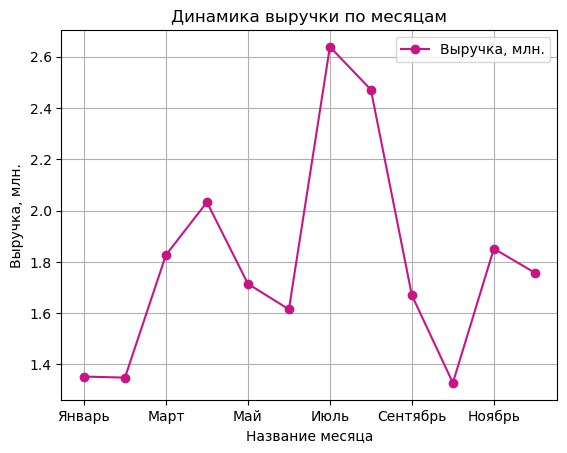

In [33]:
# Построение линейного графика 

ax = report_sales.plot(x='issue_month', y='revenue_(million)',
                  title='Динамика выручки по месяцам',
                  xlabel='Название месяца',
                  ylabel='Выручка, млн.',
                  label='Выручка, млн.',
                  color='mediumvioletred',
                  style='o-',
                  grid=True)

plt.show()

In [34]:
# Для объяснения полученных результатов рассмотрим количество билетов, купленных в каждом месяце и средний чек 

report_count_tickets = df_new.pivot_table(index='issue_month',
                                          aggfunc={'revenue_amount': ['count', 
                                                                      lambda x: round(x.mean(), 3)]}).reset_index().set_axis(['issue_month', 'mean_revenue', 'count_tickets'], axis='columns').sort_values(by='count_tickets', ascending=False)
                                                                      # анонимная функция использована для округления нецелого значения среднего чека 
report_count_tickets 

,issue_month,mean_revenue,count_tickets
3,Июль,501.698,5259
7,Ноябрь,357.939,5172
0,Август,516.244,4787
2,Декабрь,384.940,4565
6,Март,422.198,4326
1,Апрель,511.467,3974
9,Сентябрь,457.596,3648
5,Май,473.155,3623
8,Октябрь,367.314,3615
11,Январь,376.815,3589


Анализ динамики выручки, количества проданных билетов и среднего чека по месяцам выявил выраженную сезонность спроса на авиаперелеты. 

1. Низкий сезон (январь, февраль и октябрь). Данный период характеризуется наименьшей выручкой (варьируется от 1,32784 до 1,35239), минимальным объемом продаж (3454-3615 штук) и низким средним чеком (367,314-390,333). Основные факторы: постпраздничный период (истощение финансовых и эмоциональных ресурсов после новогодних праздников) и отсутствие массовых отпусков и каникул (в начале января новогодние праздники, но основной период покупки билетов приходится на декабрь). 

2. Пиковый сезон (июль и август). Данный период характеризуется наибольшей выручкой (2,63843-2,47126, что в 2 раза больше, чем в низкий сезон), максимальный объем продаж (5259-4787 штук) и высоким средним чеков (501,698-516,244). Основные факторы: открытие курортного сезона (массовые отпуска и каникулы) и благоприятные погодные условия. Следует отметить, что, судя по среднему чеку, который в августе превышает средний чек в июле, хоть купленных билетов в августе меньше, период характеризуется высокими ценами, но устойчивым спросом.

3. Особые случаи:
 - Ноябрь: при среднем уровне выручки (1,85126) наблюдается высокое количество продаж (5172 штук), что можно объяснить стимулированием к покупке после застоя продаж в октябре со стороны авиакомпании (средний чек за ноябрь невысокий, могли проводиться акции и дополнительные скидки) и раннее бронирование билетов на новогодние праздники.
 - Июнь: выручка за месяц близка к выручке по низким сезонам (1,61450 рублей), количество купленных билетов минимальное, но высокий средний чек, что говорит о высоких ценах на авиабилеты либо о покупках премиального сегмента.

Таким образом, сезонность является ключевым фактором, влияющим на общий объем выручки, количество проданных билетов и средний чек.

##### Отчет о выручке с детализацией по использованию программы лояльности.

In [35]:
# Отчет о выручке с детализацией по использованию программы лояльности (ffp_flag)

month = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'] 
# список месяцев для дальнейшей сортировки по месяцам года 

report_sales_ffp_flag = df_new.pivot_table(index='issue_month', 
                                           columns='ffp_flag',
                                           aggfunc=lambda x: x.sum() / 1_000_000, # для удобства перевожу в миллионы  
                                           values='revenue_amount').reset_index().set_axis(['issue_month', 'revenue_ffp_(million)', 'revenue_not_ffp_(million)'], axis='columns').set_index('issue_month').loc[month].reset_index()

report_sales_ffp_flag

,issue_month,revenue_ffp_(million),revenue_not_ffp_(million)
0,Январь,0.53854,0.81385
1,Февраль,0.49924,0.84897
2,Март,0.80136,1.02507
3,Апрель,0.76488,1.26769
4,Май,0.64952,1.06472
5,Июнь,0.59092,1.02358
6,Июль,0.97345,1.66498
7,Август,0.90654,1.56472
8,Сентябрь,0.53980,1.12951
9,Октябрь,0.50203,0.82581


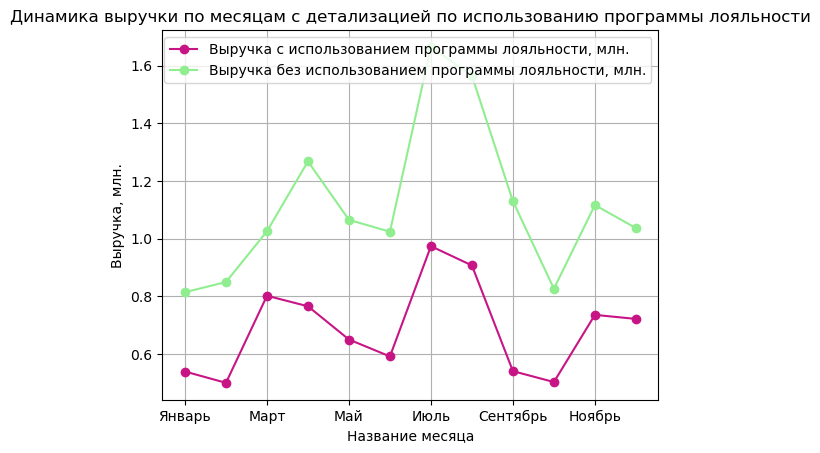

In [36]:
# Построение линейного графика 

report_sales_ffp_flag.plot(x='issue_month', y=['revenue_ffp_(million)', 'revenue_not_ffp_(million)'],
                           title='Динамика выручки по месяцам с детализацией по использованию программы лояльности',
                           xlabel='Название месяца',
                           ylabel='Выручка, млн.',
                           label=['Выручка с использованием программы лояльности, млн.', 'Выручка без использованием программы лояльности, млн.'],
                           color=['mediumvioletred', 'lightgreen'],
                           style='o-',
                           grid=True)

plt.show()

Приведенный выше график иллюстрирует ключевые аспекты динамики выручки по месяцам с детализацией по программе лояльности: 
1. Выручка без использования программы лояльности стабильно превышает выручку с использованием программы лояльности во всех месяцах;
2. Обе линии демонстрируют синхронную сезонную динамику с пиками в летние месяцы (июль и август) и спадами в низкие месяцы (январь, февраль и октябрь). Это указывает на то, что программа лояльности не сглаживает сезонные колебания;

##### Отчет о выручке с детализацией по типу перелета.

In [37]:
# Отчет о выручке с детализацией по типу перелета (route_flight_type)

month = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'] 

report_sales_route_flight_type = df_new.pivot_table(index='issue_month', 
                                                    columns='route_flight_type',
                                                    aggfunc=lambda x: x.sum() / 1_000_000, # для удобства перевожу в миллионы  
                                                    values='revenue_amount').reset_index().set_axis(['issue_month', 'revenue_vvl_(million)', 'revenue_mvl_(million)'], axis='columns').set_index('issue_month').loc[month].reset_index()

report_sales_route_flight_type

,issue_month,revenue_vvl_(million),revenue_mvl_(million)
0,Январь,1.15279,0.19960
1,Февраль,1.17337,0.17484
2,Март,1.78904,0.03739
3,Апрель,1.92643,0.10614
4,Май,1.63518,0.07906
5,Июнь,1.52381,0.09069
6,Июль,2.50780,0.13063
7,Август,2.35364,0.11762
8,Сентябрь,1.52793,0.14138
9,Октябрь,1.03902,0.28882


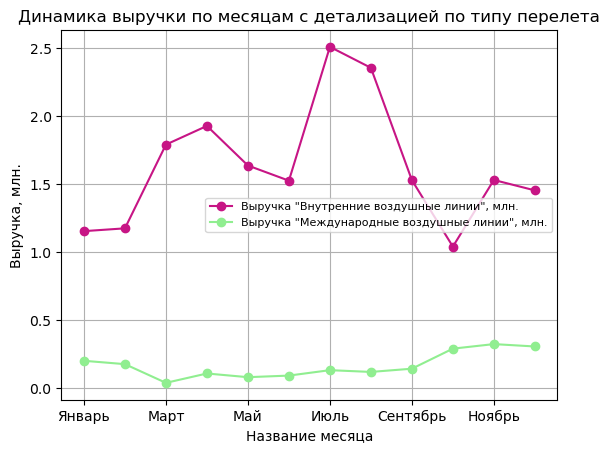

In [38]:
# Построение линейного графика 

report_sales_route_flight_type.plot(x='issue_month', y=['revenue_vvl_(million)', 'revenue_mvl_(million)'],
                           title='Динамика выручки по месяцам с детализацией по типу перелета',
                           xlabel='Название месяца',
                           ylabel='Выручка, млн.',
                           label=['Выручка "Внутренние воздушные линии", млн.', 'Выручка "Международные воздушные линии", млн.'],
                           color=['mediumvioletred', 'lightgreen'],
                           style='o-',
                           grid=True)

plt.legend(fontsize=(8))
plt.show()

Приведенный выше график иллюстрирует ключевые аспекты динамики выручки по месяцам с детализацией по типу перелета: 
1. Выручка от внутренних авиалиний (ВВЛ) значительно превышает выручку от международных направлений (МВЛ);
2. Динамика выручки по внутренним воздушным линиям демонстрирует такие же сезонные колебания, что и представленный выше график динамики общей выручки по месяцам. Перелеты по международным воздушным линиям демонстрируют иную динамику выручки по месяцам: пиковые периоды приходятся на зимний и осенний период, тогда как общий анализ динамики выручки показывал крайнюю нерентабельность этих периодов. Данную тенденцию можно объяснить тем, что международные перелеты управляются деловой активностью, которая приходится на осенние и зимние периоды, а также именно в это время многие международные направления входят в свой курортный сезон.
3. Пиковые периоды выручки по внутренним направлениям - май-июль, наиболее глубокий спад заметен в ноябре-январе. Международные перелеты демонстрируют большую устойчивость в осенне-зимний период.

##### Отчет о выручке с детализацией по способу покупки.

In [39]:
# Отчет о выручке с детализацией по способу покупки (sale_type)

month = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'] 
# создание списка месяцев для дальнейшей сортировки в порядке месяцев в году

report_sale_type = df_new.pivot_table(index='issue_month', 
                                      columns='sale_type',
                                      aggfunc=lambda x: x.sum() / 1_000_000, # для удобства перевожу в миллионы  
                                      values='revenue_amount').reset_index().set_axis(['issue_month', 'revenue_offline_(million)', 'revenue_online_(million)'], axis='columns').set_index('issue_month').loc[month].reset_index()

report_sale_type

,issue_month,revenue_offline_(million),revenue_online_(million)
0,Январь,0.62390,0.72849
1,Февраль,0.67026,0.67795
2,Март,0.79602,1.03041
3,Апрель,1.03509,0.99748
4,Май,0.74445,0.96979
5,Июнь,0.75365,0.86085
6,Июль,1.18574,1.45269
7,Август,1.23335,1.23791
8,Сентябрь,0.87149,0.79782
9,Октябрь,0.64964,0.67820


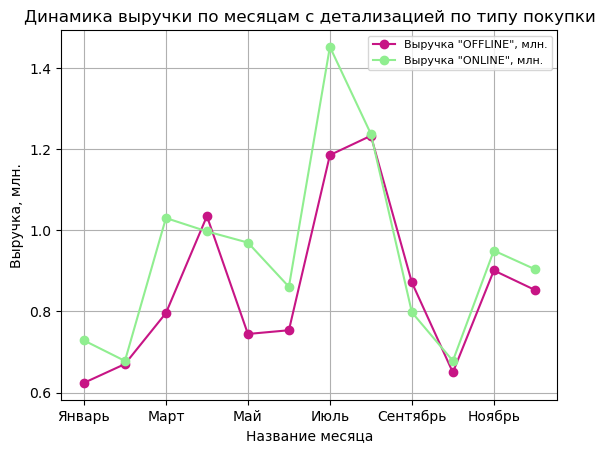

In [40]:
# Построение линейного графика 

report_sale_type.plot(x='issue_month', y=['revenue_offline_(million)', 'revenue_online_(million)'],
                      title='Динамика выручки по месяцам с детализацией по типу покупки',
                      xlabel='Название месяца',
                      ylabel='Выручка, млн.',
                      label=['Выручка "OFFLINE", млн.', 'Выручка "ONLINE", млн.'],
                      color=['mediumvioletred', 'lightgreen'],
                      style='o-',
                      grid=True)

plt.legend(fontsize=(8))
plt.show()

Приведенный выше график иллюстрирует ключевые аспекты динамики выручки по месяцам с детализацией по способу покупки: 
1. Покупка авиабилетов online стабильно превышает приобретение билетов offline, что соответствует общемировому тренду цифровизации;
2. Оба канала покупки авиабилетов демонстрируют идентичную сезонную картину: пиковый период приходится на июль и август, а низкий период - на январь, февраль и октябрь.

##### Отчет по выручке, детализированный по типам пассажиров. 

In [41]:
# Общий отчет выручки с детаизацией по типу пассажиров (для удобства категория "неопределнные" (INF) была исключена из рассмотения, так как не несет 
# статистичеки значимой информации для проведния исследования 

report_passenger_type = df_new.query('passenger_type != "INF"').pivot_table(index='passenger_type',
                                                                            aggfunc=['count', lambda x: x.sum() / 1_000_000, 
                                                                                     lambda x: round(x.mean(), 3)], 
                                                                            values='revenue_amount').reset_index().set_axis(['passenger_type', 
                                                                                                                             'count_tickets',
                                                                                                                             'revenue', 'mean_revenue'],
                                                                                                                             axis='columns')

# lambda x: x.sum() / 1_000_000 - для удобство значение выручки переведено в миллионы 
# lambda x: round(x.mean(), 3) - значение среднего чека округлено до трех знаком после запятой

report_passenger_type

,passenger_type,count_tickets,revenue,mean_revenue
0,AD,45834,20.26053,442.041
1,CHD,3445,1.33343,387.062


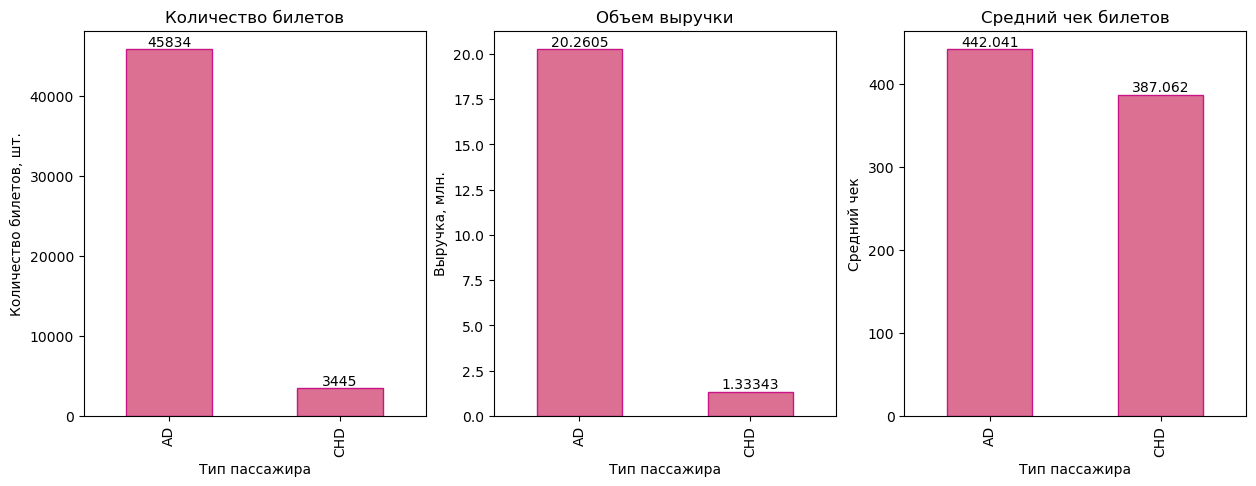

In [42]:
# Визуализация отчета 

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) # создаем сетку 1х3 для размещения графиков

# Создание отдельного графика для отображениия различий в количестве купленных билетов по типам пассажиров
ax = report_passenger_type.plot(kind='bar',
                           x='passenger_type',
                           y='count_tickets',
                           title='Количество билетов',
                           xlabel='Тип пассажира',
                           ylabel='Количество билетов, шт.',
                           color='palevioletred',
                           edgecolor='mediumvioletred',
                           legend=False,
                           ax=axs[0]) # размещаем график в первой из трех созданных ячеек 

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

# Создание графика для отображения различий в общем объеме выручки, полученной от продажи билетов по типам пассажиров
ax = report_passenger_type.plot(kind='bar',
                           x='passenger_type',
                           y='revenue',
                           title='Объем выручки',
                           xlabel='Тип пассажира',
                           ylabel='Выручка, млн.',
                           color='palevioletred',
                           edgecolor='mediumvioletred',
                           legend=False,
                           ax=axs[1]) # размещаем график во второй из трех созданных ячеек

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

# Создание графика для отображения различий в среднем чеке между билетами, купленными разными типами пассажиров
ax = report_passenger_type.plot(kind='bar',
                           x='passenger_type',
                           y='mean_revenue',
                           title='Средний чек билетов',
                           xlabel='Тип пассажира',
                           ylabel='Средний чек',
                           color='palevioletred',
                           edgecolor='mediumvioletred',
                           legend=False,
                           ax=axs[2]) # размещаем график в третьей из трех созданных ячеек

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

plt.show()

Представленный анализ позволяет выявить ключевые особенности зависимости выручки от типа пассажиров, покупающих авиабилеты:

1.	Количественное преобладание билетов, купленных взрослыми пассажирами: 93% покупок было совершено взрослыми пассажирами (45834 билета против 3445 билетов, купленных по категории "дети");
2.	Выручка от взрослых билетов превышает детскую в 15,2 раза (20,2605 млн. против 1,33343 млн.). Доля выручки от взрослых составляет 94% от общей выручки;
3.	Средний чек детского билета ниже на 6%, следовательно, цены на детские билеты ниже, чем на взрослые.

Основные факторы:

- Взрослые составляют основную массу платежеспособно населения, часто осуществляют деловые поездки и летаю регулярнее, чем дети. Поэтому перевес количества купленных билетов в пользу взрослой аудитории оправдан;
- В различных сферах детские тарифы ниже взрослых. В представленных данных повторяется данная тенденция.

##### Отчет по выручке, детализированный по типам перелетов. 

In [43]:
# Общий отчет выручки с детаизацией по типу перелетов 

report_rft = df_new.pivot_table(index='route_flight_type',
                                aggfunc=['count', lambda x: round(x.mean(), 3), lambda x: x.sum() / 1_000_000],
                                values='revenue_amount').reset_index().set_axis(['route_flight_type', 
                                                                                 'count_tickets', 'mean_revenue', 
                                                                                 'revenue'], axis='columns')

# lambda x: x.sum() / 1_000_000 - для удобство значение выручки переведено в миллионы 
# lambda x: round(x.mean(), 3) - значение среднего чека округлено до трех знаком после запятой

report_rft

,route_flight_type,count_tickets,mean_revenue,revenue
0,ВВЛ,45468,431.303,19.61048
1,МВЛ,3897,511.473,1.99321


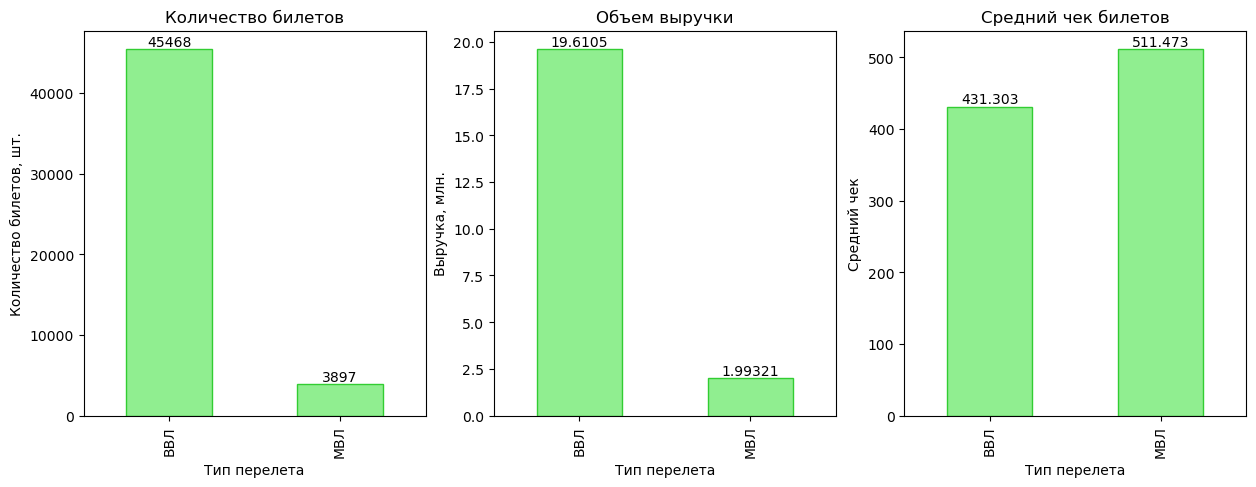

In [44]:
# Визуализация отчета 

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) # создаем сетку 1х3 для размещения графиков

# Создание отдельного графика для отображениия различий в количестве купленных билетов по типам перелетов
ax = report_rft.plot(kind='bar',
                     x='route_flight_type',
                     y='count_tickets',
                     title='Количество билетов',
                     xlabel='Тип перелета',
                     ylabel='Количество билетов, шт.',
                     color='lightgreen',
                     edgecolor='limegreen',
                     legend=False,
                     ax=axs[0]) # размещаем график в первой из трех созданных ячеек 

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

# Создание графика для отображения различий в общем объеме выручки, полученной от продажи билетов по типам перелетов
ax = report_rft.plot(kind='bar',
                     x='route_flight_type',
                     y='revenue',
                     title='Объем выручки',
                     xlabel='Тип перелета',
                     ylabel='Выручка, млн.',
                     color='lightgreen',
                     edgecolor='limegreen',
                     legend=False,
                     ax=axs[1]) # размещаем график во второй из трех созданных ячеек

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

# Создание графика для отображения различий в среднем чеке между билетами по типам перелетов
ax = report_rft.plot(kind='bar',
                     x='route_flight_type',
                     y='mean_revenue',
                     title='Средний чек билетов',
                     xlabel='Тип перелета',
                     ylabel='Средний чек',
                     color='lightgreen',
                     edgecolor='limegreen',
                     legend=False,
                     ax=axs[2]) # размещаем график в третьей из трех созданных ячеек

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

plt.show()

Анализ типа перелета показал, что наибольший спрос клиентов авиакомпании направлен на перелеты по внутренним воздушным линиям: 92% купленных авиабилетов приходится на ВВЛ, что на 84% больше, чем количество билетов, купленных для перелетов по международным воздышным линиям. Основные факторы:

Данные по продажак авиабилетов предоставлены за 2021-2022 гг. В этот период Российская Федерация находилась в сложной политической ситуации, повергшей наложение санкций на страну. Часть этих санкций ограничила международные перелеты;
Кардинально отличаются цены на авиабилеты: выручка от билетов купленных для МВЛ на 82% ниже выручки, поступающей от билетов для ВВЛ, количество купленных билетов, как было установлено выше, различается на 84%, а средний чек по МВЛ значительно выше (выше на 10%). Следовательно, многие могут склоняться к внутреннем туризму, ориентируясь на более низкую цену билетов.

##### Отчет по выручке, детализированный по способам покупки. 

In [45]:
# Общий отчет выручки с детаизацией по способу покупки

report_sale = df_new.pivot_table(index='sale_type',
                                 aggfunc=['count', lambda x: round(x.mean(), 3), lambda x: x.sum() / 1_000_000],
                                 values='revenue_amount').reset_index().set_axis(['sale_type', 
                                                                                  'count_tickets', 
                                                                                  'mean_revenue', 'revenue'], 
                                                                                  axis='columns')

# lambda x: x.sum() / 1_000_000 - для удобство значение выручки переведено в миллионы 
# lambda x: round(x.mean(), 3) - значение среднего чека округлено до трех знаком после запятой

report_sale

,sale_type,count_tickets,mean_revenue,revenue
0,OFFLINE,21627,477.079,10.31778
1,ONLINE,27738,406.875,11.28591


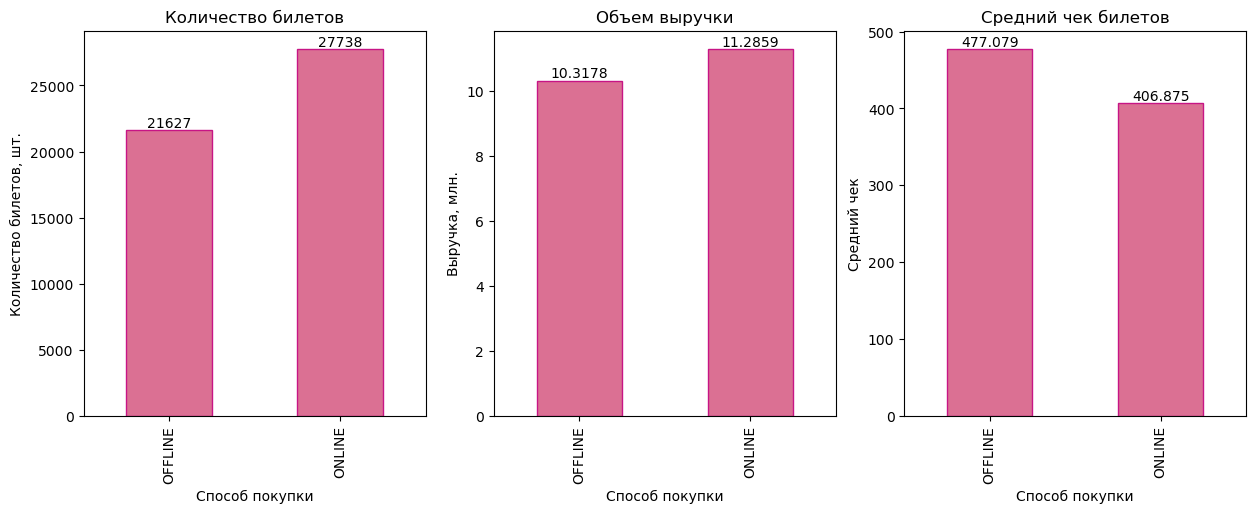

In [46]:
# Визуализация отчета 

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) # создаем сетку 1х3 для размещения графиков

# Создание отдельного графика для отображениия различий в количестве купленных билетов по типам пассажиров
ax = report_sale.plot(kind='bar',
                      x='sale_type',
                      y='count_tickets',
                      title='Количество билетов',
                      xlabel='Способ покупки',
                      ylabel='Количество билетов, шт.',
                      color='palevioletred',
                      edgecolor='mediumvioletred',
                      legend=False,
                      ax=axs[0]) # размещаем график в первой из трех созданных ячеек 

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

# Создание графика для отображения различий в общем объеме выручки, полученной от продажи билетов по типам пассажиров
ax = report_sale.plot(kind='bar',
                      x='sale_type',
                      y='revenue',
                      title='Объем выручки',
                      xlabel='Способ покупки',
                      ylabel='Выручка, млн.',
                      color='palevioletred',
                      edgecolor='mediumvioletred',
                      legend=False,
                      ax=axs[1]) # размещаем график во второй из трех созданных ячеек

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

# Создание графика для отображения различий в среднем чеке между билетами, купленными разными типами пассажиров
ax = report_sale.plot(kind='bar',
                      x='sale_type',
                      y='mean_revenue',
                      title='Средний чек билетов',
                      xlabel='Способ покупки',
                      ylabel='Средний чек',
                      color='palevioletred',
                      edgecolor='mediumvioletred',
                      legend=False,
                      ax=axs[2]) # размещаем график в третьей из трех созданных ячеек

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

plt.show()

Представленный анализ позволяет выявить ключевые особенности каналов продаж ранка авиабилетов: 

1. Количественной преобладание онлайн-заказов: 56% покупок авиабилетов совершается online (27738 билетов против 21627 билетов, купленных offline);
2. Общая выручка обоих каналов практически равна (11,2859 млн. online и 10,3178 млн. offline).

Однако при таком соотношении в количестве купленных билетов и полученной выручке средний чек по offline продажам значительно превышает средний чек online продаж (выше на 8%) 

Данную тенденцию можно объяснить следующими факторами: 

- зачастую многие сервисы предлагают сниженные цены на online покупки, так как offline покупки сопряжены с личной встречей с продавцом, который консультирует клиентов, решает нестандартные вопросы и задачи;
- покупки билетов offline могут быть сопряжены с продажи дополнительны услуг, которые эффективнее реализуются при личном взаимодействии;
- online сервис является наиболее популярным в силу своего удобства и скорости.

##### Отчет по выручке, детализированный по прогрмме лояльности. 

In [47]:
# Общий отчет выручки с детаизацией по программе лояльности 

report_ffp = df_new.pivot_table(index='ffp_flag', 
                                aggfunc=['count', lambda x: x.sum() / 1_000_000, lambda x: round(x.mean(), 3)], 
                                values='revenue_amount').reset_index().set_axis(['ffp_flag', 'count_tickets', 
                                                                                 'revenue', 'mean_revenue'], axis='columns')

# lambda x: x.sum() / 1_000_000 - для удобство значение выручки переведено в миллионы 
# lambda x: round(x.mean(), 3) - значение среднего чека округлено до трех знаком после запятой

report_ffp

,ffp_flag,count_tickets,revenue,mean_revenue
0,FFP,19336,8.22239,425.237
1,NOT_FFP,30029,13.38130,445.613


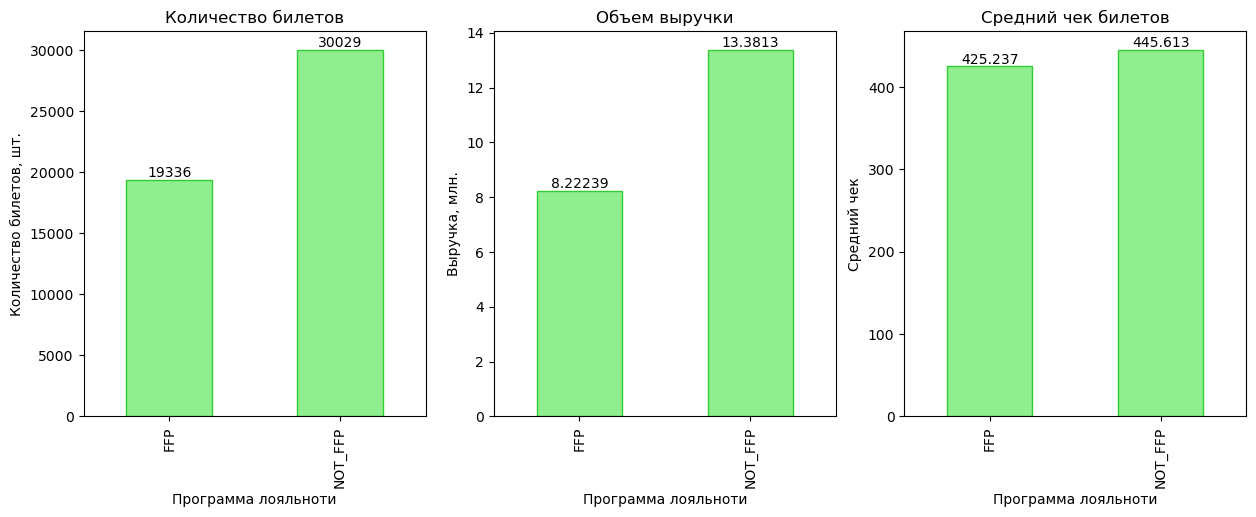

In [48]:
# Визуализация отчета 

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) # создаем сетку 1х3 для размещения графиков

# Создание отдельного графика для отображениия различий в количестве купленных билетов по типам перелетов
ax = report_ffp.plot(kind='bar',
                     x='ffp_flag',
                     y='count_tickets',
                     title='Количество билетов',
                     xlabel='Программа лояльноти',
                     ylabel='Количество билетов, шт.',
                     color='lightgreen',
                     edgecolor='limegreen',
                     legend=False,
                     ax=axs[0]) # размещаем график в первой из трех созданных ячеек 

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

# Создание графика для отображения различий в общем объеме выручки, полученной от продажи билетов по типам перелетов
ax = report_ffp.plot(kind='bar',
                     x='ffp_flag',
                     y='revenue',
                     title='Объем выручки',
                     xlabel='Программа лояльноти',
                     ylabel='Выручка, млн.',
                     color='lightgreen',
                     edgecolor='limegreen',
                     legend=False,
                     ax=axs[1]) # размещаем график во второй из трех созданных ячеек

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

# Создание графика для отображения различий в среднем чеке между билетами по типам перелетов
ax = report_ffp.plot(kind='bar',
                     x='ffp_flag',
                     y='mean_revenue',
                     title='Средний чек билетов',
                     xlabel='Программа лояльноти',
                     ylabel='Средний чек',
                     color='lightgreen',
                     edgecolor='limegreen',
                     legend=False,
                     ax=axs[2]) # размещаем график в третьей из трех созданных ячеек

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

plt.show()

Анализ эффективности программы лояльности выявил системные проблемы в ее реализации: 
- на 22% меньше покупок билетов по программе лояльности (19336 штук) по сравнению с количеством билетов, приобретенных без использования программы (30029 штук);
- на 24% меньше выручка, полученная от покупок авиабилетов по программе лояльности (8,22239 млн.);
- средний чек по билетам, купленным по программе лояльности на 4% ниже. Это различие в средних чеках является подтверждением применения дополнительных скидок.

Проведенный анализ позволил выявить неэффективность проведения программы лояльности в представленной авиакомпании. Программа не выполняет ключевую задачу - не стимулирует дополнительные покупки. Именно проведение качественной программы лояльности могло бы помочь реабилитировать ситуацию с низкими сезонами, однако динамика по месяцам повторяет общий тренд без усиления в выручки в проседающие сезоны. Данная тенденция может быть вызвана:
- небольшими скидками по программе лояльности, которые почти не влияют на стоимость билета;
- большим количеством условий для получения заметной скидки;
- привлечением не той категории клиентов: отсутствие ориентации на прибыльных клиентов.

<div class="alert alert-block alert-success">

#### Вывод 
В ходе анализа динамики продаж (выручки) были выявлены ключевые особенности: 
1. Сезонность является ключевым фактором, влияющим на общий объем выручки, количество проданных билетов и средний чек.
2. Взрослые пассажиры являются целевой аудиторией для бизнеса авиакомпании, в то время как детский сегмент, несмотря на меньший финансовый вклад, важен для формирования лояльности семейной аудитории и долгосрочного развития клиентской базы.
3. В анализируемый период клиенты авиакомпании преимущественно ориентированы на перелеты по внутренним воздушным линиям. Международные перелеты, несмотря на более высокий средний чек, носят нишевый характер в текущих условиях. сезонность международных перелетов демонстрирует иную динамику выручки с пиковыми периодами в осенние и зимние сезоны.
4. В современных условиях при покупке билетов клиенты авиакомпании ориентируются на приобретение билетов online. Данный способ покупки сопровождается дополнительными скидками от авиакомпании. 
5. Выручка без использования программы лояльности стабильно превышает выручку с использованием программы лояльности во всех месяцах. Текущая программа показывает неэффективные результаты, не привлекаю дополнительных клиентов и не создавая ценности для авиакомпании. 

#### Задание 3.2

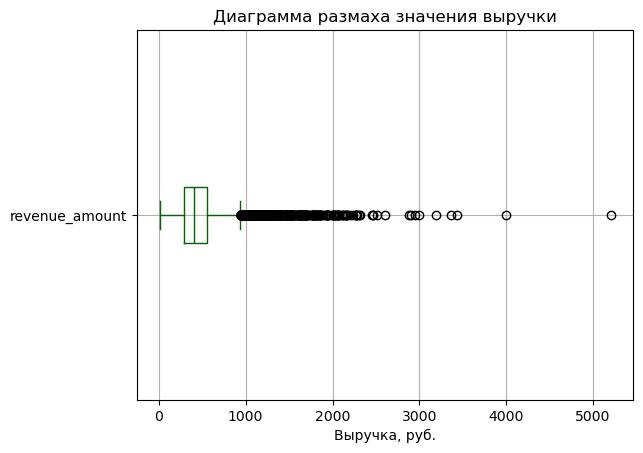

In [49]:
# Исследование выручки на наличе выбросов 

df_new['revenue_amount'].plot(kind='box', # диаграмма размаха 
                              color='darkgreen',
                              vert=False, # горизонтальное положение графика 
                              title='Диаграмма размаха значения выручки',
                              xlabel='Выручка, руб.',
                              grid=True)

plt.show()

Таким образом, в представленных данных значения выручки имеют выбросы. Необходимо проанализировать количество выбросов и их долю в данных, чтобы принять решение об их исключении для дальнейшего анализа с минимизацией потерь.

In [50]:
# Найдем значения границ усов (верхнего уса), количества выбросов и долю выбрасов в данных 

q75 = np.percentile(df_new['revenue_amount'], 75) # значение 75-го перцентиля
q25 = np.percentile(df_new['revenue_amount'], 25) # значение 25-го перцентиля
iqr = q75 - q25 # межквартильный размах
ejection_h = q75 + 1.5 * iqr # граница верхнего уса 
ejection_count = df_new['revenue_amount'][(df_new['revenue_amount'] > ejection_h)].count() # количество выбросов 
ejection_perc = (ejection_count / len(df_new['revenue_amount'])) * 100 # доля выбросов в данных 

print(f'Верхняя граница усов = {ejection_h}')
print(f'Количество выбросов = {ejection_count}')
print(f'Доля выбросов в данных = {ejection_perc:.3f}%')

Верхняя граница усов = 940.0
Количество выбросов = 987
Доля выбросов в данных = 1.999%


Таким образом, в данных 987 выбросов, что соствляет 2% от датасета. Проанализируем выбросы для принятия решения об их исключении.

In [51]:
# Рассмотри выбросы в данных
ejection = df_new.query('revenue_amount > @ejection_h') # создание отдельной таблицы, содержащей только выбросы 
ejection

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month
15,2022-01-07,2022-01-15,AD,1090,GDZ,MOW,ВВЛ,NOT_FFP,OFFLINE,2022,Январь
81,2022-01-07,2022-01-08,AD,1820,OVB,KHV,ВВЛ,NOT_FFP,OFFLINE,2022,Январь
120,2021-12-06,2022-01-15,AD,1030,BKK,KHV,МВЛ,FFP,OFFLINE,2021,Декабрь
167,2021-12-12,2022-01-04,AD,960,MOW,AER,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь
216,2021-12-24,2022-01-02,AD,2000,IKT,MOW,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь
...,...,...,...,...,...,...,...,...,...,...,...
49458,2021-10-16,2021-12-20,AD,1310,VVO,HKT,МВЛ,FFP,ONLINE,2021,Октябрь
49565,2022-04-15,2022-05-04,AD,960,HTA,MOW,ВВЛ,NOT_FFP,OFFLINE,2022,Апрель
49656,2022-04-08,2022-05-21,AD,970,VVO,OVB,ВВЛ,FFP,OFFLINE,2022,Апрель
49800,2022-06-28,2022-06-30,AD,950,MOW,HTA,ВВЛ,NOT_FFP,OFFLINE,2022,Июнь


In [52]:
# Проанализируем, есть ли экстримальные значения по международным воздушным линиям, так как выше было установлено, что средний чек по ним выше 
ejection.query('revenue_amount > @ejection_h and route_flight_type == "МВЛ"')

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month
120,2021-12-06,2022-01-15,AD,1030,BKK,KHV,МВЛ,FFP,OFFLINE,2021,Декабрь
259,2021-12-09,2022-01-31,AD,950,HKT,VVO,МВЛ,NOT_FFP,ONLINE,2021,Декабрь
403,2021-10-31,2021-11-14,AD,1140,VVO,SEL,МВЛ,NOT_FFP,ONLINE,2021,Октябрь
536,2021-11-11,2021-11-12,AD,1110,OVB,BAK,МВЛ,FFP,ONLINE,2021,Ноябрь
855,2021-11-04,2021-11-05,AD,1930,ALC,MOW,МВЛ,NOT_FFP,OFFLINE,2021,Ноябрь
...,...,...,...,...,...,...,...,...,...,...,...
47102,2021-11-02,2021-11-21,AD,1030,SEL,VVO,МВЛ,NOT_FFP,OFFLINE,2021,Ноябрь
47823,2022-07-11,2022-09-21,AD,1170,TLV,MOW,МВЛ,NOT_FFP,ONLINE,2022,Июль
49042,2022-09-30,2022-10-01,AD,1510,MOW,AYT,МВЛ,NOT_FFP,ONLINE,2022,Сентябрь
49434,2021-11-26,2021-12-12,AD,1550,VVO,SEL,МВЛ,NOT_FFP,OFFLINE,2021,Ноябрь


Таким образом, 129 выбросов являются не ошибкой при сборе данных, а обусловлены высокой стоимостью перелетов по Международным Воздушным Линиям.

In [53]:
# Рассмотри выбросы в значениях выручки только для Внутренних Воздушных Линий, так как они могут быть вызваны ошибками в сборе данных 
ejection = ejection.query('revenue_amount > @ejection_h and route_flight_type == "ВВЛ"')
len(ejection)

858

Я считаю, что экстремальные значения выручки могут быть вызваны покупкой билетов за 7 дней до вылета, так как именно в это время стоимость билетов в среднем увеличивает на 50-150% и большими расстояниеми между городами. 
Для анализа этих двух предположений необходимо в таблице с выбросами создать два вспомогательных столбца: количество дней между датой покупки билета и датой вылета (count_days) и расстояние прелета (distance). 

In [54]:
# Создание столбца с количеством дней между датой покукпи билета и датой вылета 
ejection['count_days'] = (ejection['flight_date'] - ejection['issue_date']).dt.days
ejection.head() # проверка

C:\Users\Алина\AppData\Local\Temp\ipykernel_20656\1765628501.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ejection['count_days'] = (ejection['flight_date'] - ejection['issue_date']).dt.days


,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,count_days
15,2022-01-07,2022-01-15,AD,1090,GDZ,MOW,ВВЛ,NOT_FFP,OFFLINE,2022,Январь,8
81,2022-01-07,2022-01-08,AD,1820,OVB,KHV,ВВЛ,NOT_FFP,OFFLINE,2022,Январь,1
167,2021-12-12,2022-01-04,AD,960,MOW,AER,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,23
216,2021-12-24,2022-01-02,AD,2000,IKT,MOW,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь,9
348,2021-10-30,2021-11-14,AD,1030,MOW,NJC,ВВЛ,FFP,ONLINE,2021,Октябрь,15


In [55]:
# В задании была дана ссылка на вспомогательную таблицу по аэропортам, выведем ее
df_airport = pd.read_csv('https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat', header=None)
# Python воспринимает первую строку таблицы как заголовок, поэтому понадобилось применение header=None

# Переименуем заголовки таблицы 
column_names = ['Index', 'Airport Name', 'Location', 'Country', 'IATA_Code', 'ICAO_Code', 'Latitude', 'Longitude', 'Altitude', 'Timezone', 'DST', 'Timezone Region', 'Type', 'Source']
df_airport.columns = column_names
df_airport.columns = df_airport.columns.str.lower() # переведем названия в нижний регистр

df_airport.head() # проверка 

,index,airport name,location,country,iata_code,icao_code,latitude,longitude,altitude,timezone,dst,timezone region,type,source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports


Для определения расстояния перелета нам нужны координаты широты и долготы. Коды аэропортов совпадают по системе IATA, так как коды в данных состоят из трех символов, а не из четырех, как по системе ICAO. Необходимо объединить таблицы.

In [56]:
# Сначала получим широту и долготу для городов отправления. Для этого необходимо, чтобы столбец с кодом аэропорта в обеих таблицах совпадал
df_airport = df_airport.rename(columns={'iata_code': 'departure_city_code'})	

# Добавим в таблицу с выбросами широту и долготу городов отправления 
ejection = ejection.merge(df_airport[['departure_city_code', 'latitude', 'longitude']], on='departure_city_code', how='left')

# Переменуем добавленные столбцы 
ejection = ejection.rename(columns={'latitude': 'latitude_departure',
                                    'longitude': 'longitude_departure'})

len(ejection)

858

In [57]:
# Получим широту и долготу для городов прибытия. Для этого необходимо, чтобы столбец с кодом аэропорта в обеих таблицах совпадал
df_airport = df_airport.rename(columns={'departure_city_code': 'dest_city_code'})	

# Добавим в таблицу с выбросами широту и долготу городов отправления 
ejection = ejection.merge(df_airport[['dest_city_code', 'latitude', 'longitude']], on='dest_city_code', how='left')

# Переменуем добавленные столбцы 
ejection = ejection.rename(columns={'latitude': 'latitude_dest',
                                    'longitude': 'longitude_dest'})

len(ejection)

858

In [58]:
ejection.head()

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,count_days,latitude_departure,longitude_departure,latitude_dest,longitude_dest
0,2022-01-07,2022-01-15,AD,1090,GDZ,MOW,ВВЛ,NOT_FFP,OFFLINE,2022,Январь,8,44.582093,38.012481,NaN,NaN
1,2022-01-07,2022-01-08,AD,1820,OVB,KHV,ВВЛ,NOT_FFP,OFFLINE,2022,Январь,1,55.012600,82.650703,48.528000,135.188004
2,2021-12-12,2022-01-04,AD,960,MOW,AER,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,23,NaN,NaN,43.449902,39.956600
3,2021-12-24,2022-01-02,AD,2000,IKT,MOW,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь,9,52.268002,104.389000,NaN,NaN
4,2021-10-30,2021-11-14,AD,1030,MOW,NJC,ВВЛ,FFP,ONLINE,2021,Октябрь,15,NaN,NaN,60.949299,76.483597


In [59]:
ejection.isna().sum()

issue_date               0
flight_date              0
passenger_type           0
revenue_amount           0
departure_city_code      0
dest_city_code           0
route_flight_type        0
ffp_flag                 0
sale_type                0
issue_year               0
issue_month              0
count_days               0
latitude_departure     219
longitude_departure    219
latitude_dest          228
longitude_dest         228
dtype: int64

Получившаяся таблица имеет пропущенные значения, которые необоходимо обработать. Установим, есть ли закономерность в пропущенных значениях.

In [60]:
ejection[ejection['latitude_departure'].isna()]['departure_city_code']

2      MOW
4      MOW
11     MOW
15     MOW
18     MOW
      ... 
841    MOW
843    MOW
844    MOW
848    MOW
856    MOW
Name: departure_city_code, Length: 219, dtype: object

In [61]:
ejection[ejection['latitude_departure'].isna()]['dest_city_code']

2      AER
4      NJC
11     NSK
15     OVB
18     SIP
      ... 
841    BQS
843    UUD
844    HTA
848    KEJ
856    HTA
Name: dest_city_code, Length: 219, dtype: object

Таким образом, все пропущенные значения - "MOW", широта и долгота которого отстуствует в дополнительной таблице. Необоходимо заменить пропущенные значения. Данные пропуски связаны с тем, что это код московского авиационного узла, который подразуемвает все аэропорты Москвы и не имеет единых координат. Удаление значений приведет к большим потерям в данных, поэтому пропуски будут заменены координатами аэропорта Шереметьево, который является одним из главных узлов.  

Позже было установлено, что есть пропуски по GRV. Но так как их всего три, было принято исключить их из рассмотрения.

In [62]:
ejection['latitude_departure'] = ejection['latitude_departure'].fillna(55.972642)
ejection['latitude_dest'] = ejection['latitude_dest'].fillna(55.972642)
ejection['longitude_departure'] = ejection['longitude_departure'].fillna(37.414589)
ejection['longitude_dest'] = ejection['longitude_dest'].fillna(37.414589)

In [63]:
# Исключение кодов аэропорта с пропущенными значениями
ejection = ejection.query('departure_city_code != "GRV"')

In [64]:
# Для определения расстояния между городами необоходимо воспользоваться формулой гаверсинуса 
# Напишем функцию, которая на вход будет принимать координаты широты и долготы, а на выход выдавать расстояние в км 

def haversine(lat1, lon1, lat2, lon2):
    R = 6371 # радиус Земли в км

    # координаты нужно перевести в радианы 
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    # для того, чтобы не запутаться в рассчетах, буду делать их по шагам
    # найдем разницу между координами, деленную на 2
    a = ((lat2 - lat1) / 2)
    b = ((lon2 - lon1) / 2)

    c = np.sin(a) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(b) ** 2
    d = round(2 * np.arcsin(np.sqrt(c)), 3)

    return R * d

In [65]:
# Применение функции
ejection['distance_km'] = haversine(ejection['latitude_departure'], ejection['longitude_departure'], ejection['latitude_dest'], ejection['longitude_dest'])

In [66]:
ejection.head() # проверка 

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,count_days,latitude_departure,longitude_departure,latitude_dest,longitude_dest,distance_km
0,2022-01-07,2022-01-15,AD,1090,GDZ,MOW,ВВЛ,NOT_FFP,OFFLINE,2022,Январь,8,44.582093,38.012481,55.972642,37.414589,1267.829
1,2022-01-07,2022-01-08,AD,1820,OVB,KHV,ВВЛ,NOT_FFP,OFFLINE,2022,Январь,1,55.012600,82.650703,48.528000,135.188004,3599.615
2,2021-12-12,2022-01-04,AD,960,MOW,AER,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,23,55.972642,37.414589,43.449902,39.956600,1401.620
3,2021-12-24,2022-01-02,AD,2000,IKT,MOW,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь,9,52.268002,104.389000,55.972642,37.414589,4211.231
4,2021-10-30,2021-11-14,AD,1030,MOW,NJC,ВВЛ,FFP,ONLINE,2021,Октябрь,15,55.972642,37.414589,60.949299,76.483597,2299.931


Теперь я хочу проверить, если ли выбросы, которые вызваны ошибкой, то есть перелеты с заранее купленными билетами, но небольшой дистанцией между городами.

###### В России существует классификация пассажирских самолётов по дальности полёта:

- Дальнемагистральные — способны преодолевать более 6 тыс. км
- Среднемагистральные — с дальностью полёта 2,5–6 тыс. км.
- Ближнемагистральные — для маршрутов на 1–2,5 тыс. км.
- Местные — летающие на расстояние менее 1 тыс. км.

(https://tourweek.ru/articles/transport/315582)

In [67]:
# Исключим из рассмотрения города, дистанция между которыми очень большая 
ejection_1 = ejection.query('distance_km <= 1000') # таблица, содержащая только местные перелеты
# Проверяем количество дней между покупкой билета и датой вылета 
ejection_1.query('count_days > 7')

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,count_days,latitude_departure,longitude_departure,latitude_dest,longitude_dest,distance_km
722,2022-04-27,2022-05-12,AD,1040,OVB,OMS,ВВЛ,FFP,OFFLINE,2022,Апрель,15,55.0126,82.650703,54.966999,73.310501,592.503


In [68]:
ejection_2 = ejection.query('distance_km <= 2500') # таблица, содержащая только ближнемагистральные перелеты
# Проверяем количество дней между покупкой билета и датой вылета 
ejection_2.query('count_days > 7')

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,count_days,latitude_departure,longitude_departure,latitude_dest,longitude_dest,distance_km
0,2022-01-07,2022-01-15,AD,1090,GDZ,MOW,ВВЛ,NOT_FFP,OFFLINE,2022,Январь,8,44.582093,38.012481,55.972642,37.414589,1267.829
2,2021-12-12,2022-01-04,AD,960,MOW,AER,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,23,55.972642,37.414589,43.449902,39.956600,1401.620
4,2021-10-30,2021-11-14,AD,1030,MOW,NJC,ВВЛ,FFP,ONLINE,2021,Октябрь,15,55.972642,37.414589,60.949299,76.483597,2299.931
5,2021-11-07,2021-11-17,AD,1200,KRR,MOW,ВВЛ,FFP,ONLINE,2021,Ноябрь,10,45.034698,39.170502,55.972642,37.414589,1223.232
16,2021-12-06,2022-01-03,AD,1070,SIP,MOW,ВВЛ,FFP,ONLINE,2021,Декабрь,28,45.052200,33.975101,55.972642,37.414589,1235.974
24,2022-04-14,2022-08-27,AD,1760,AER,MOW,ВВЛ,NOT_FFP,ONLINE,2022,Апрель,135,43.449902,39.956600,55.972642,37.414589,1401.620
27,2022-02-17,2022-03-05,AD,1090,OVB,NSK,ВВЛ,NOT_FFP,OFFLINE,2022,Февраль,16,55.012600,82.650703,69.311096,87.332199,1605.492
29,2021-12-10,2022-01-02,AD,1260,MOW,AAQ,ВВЛ,FFP,ONLINE,2021,Декабрь,23,55.972642,37.414589,45.002102,37.347301,1216.861
43,2021-10-14,2021-11-07,AD,1190,OVB,IKT,ВВЛ,FFP,ONLINE,2021,Октябрь,24,55.012600,82.650703,52.268002,104.389000,1458.959
44,2021-10-18,2021-11-04,AD,1070,SIP,MOW,ВВЛ,NOT_FFP,ONLINE,2021,Октябрь,17,45.052200,33.975101,55.972642,37.414589,1235.974


Полученные данные очень похожи на ошибочные и требующие исключения, но также цена по этим билетам может быть высокой из-за покупки билетов в бизнес класс, что невозможно проверить по имеющимся данными. Иключение этих выбросов из рассмотрение может привести к серьезным потерям в области привелигированного сегмента.

<div class="alert alert-block alert-success">

#### Вывод 

Таким образом, проделанный анализ позволяет сделать вывод о том, что у выбросов в данных есть своя природа и они не являются ошибками в сборе данных. Было установлены, что перелеты, цены по которым являются выбросами, имеют:

- Тип перелета по Международным Воздушным Линиям;
- Длинную дистанцию перелета;
- Билеты по таким рейсам были куплены в день вылеты или в течение недели до него;
- Билеты были куплены в бизнес-класс или с использованием иных дополнительных улуг.

Для проведения дальнейшего исследования принято решение не удалять выбросы, а создать отдельный датасет без них и проводить анализ особо чувствительных к выбросам тестов на двух датасетах. Это позволит проводить дополнительный анализ и не лишится важных составлябщих данных.

In [69]:
# Создание датасета без выбросов
df_not_ejection = df_new.query('revenue_amount < @ejection_h')

#### Задание 3.3

In [70]:
# Исследование сезонности продаж 
# Напишем функцию, которой на вход будет подаваться месяц покупки билета, а на выходу мы будем получать сезон 

def season(month):

    if month == 'Декабрь' or month == 'Январь' or month == 'Февраль':
        return 'Зима'
    if month == 'Март' or month == 'Апрель' or month == 'Май':
        return 'Весна'
    if month == 'Июнь' or month == 'Июль' or month == 'Август':
        return 'Лето'
    if month == 'Сентябрь' or month == 'Октябрь' or month == 'Ноябрь':
        return 'Осень'

In [71]:
# Создадим отдельный столбец с сезоном 

df_new['issue_season'] = df_new['issue_month'].apply(season)
df_new.head() # проверка

C:\Users\Алина\AppData\Local\Temp\ipykernel_20656\1890890938.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['issue_season'] = df_new['issue_month'].apply(season)


,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,issue_season
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь,Зима
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,Ноябрь,Осень
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021,Декабрь,Зима


In [72]:
# Создадим отдельный столбец с сезонами для таблицы, несодержащей выбросов 

df_not_ejection['issue_season'] = df_not_ejection['issue_month'].apply(season)

C:\Users\Алина\AppData\Local\Temp\ipykernel_20656\1691591925.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_not_ejection['issue_season'] = df_not_ejection['issue_month'].apply(season)


In [73]:
# Отчет динамики выручки, детализированный по сезону 

df_season = df_new.pivot_table(index='issue_season',
                               aggfunc=lambda x: x.sum() / 1_000_000, # перевод в миллионы для удобства
                               values='revenue_amount').reset_index().set_axis(['issue_season', 'revenue'], 
                                                                               axis='columns').sort_values(by='revenue',
                                                                                                           ascending=False)

df_season

,issue_season,revenue
2,Лето,6.72419
0,Весна,5.57324
3,Осень,4.84841
1,Зима,4.45785


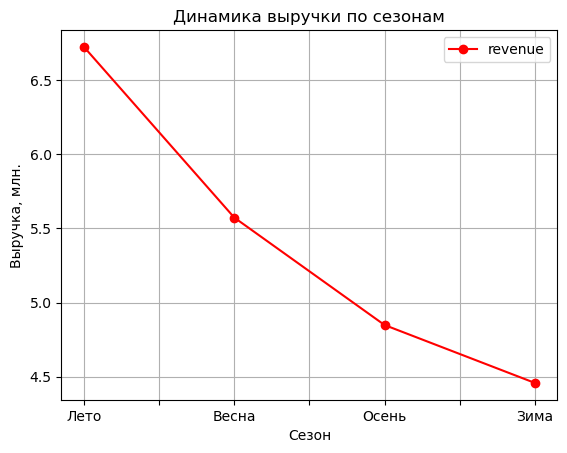

In [74]:
# Визуализируем на линейном графике 

df_season.plot(x = 'issue_season',
               y = 'revenue',
               title = 'Динамика выручки по сезонам',
               xlabel = 'Сезон',
               ylabel = 'Выручка, млн.',
               style = 'o-',
               grid=True,
               color = 'red')

plt.show()

Анализ зависимости динамики выручки от сезона позволяет сделать несколько ключевых выводов, подтверждающих ранее полученные результаты: 

1. Выручка от продаж авиабилетов зимой минимальная (4,45785 млн.), поскольку именно на зимний период приходится месяцы спада продаж авиабилетов январь и февраль;
2. Лето имеет пик выручки от продажи авиабилетов (6,72419 млн.), именно в это время начинается курортный сезон и пиковые месяцы продаж июль и август приносят максимальную выручку;
3. Выручка осенью составила (4,84841 млн.) и несильно отличается от выручки зимой, поскольку в этот сезон есть еще один месяц спада выручки - октябрь;
4. Весна демонтрирует средний показатель объема выручки - 5,57324 млн.

In [75]:
# Создание отдельного отчета для анализа количества продаж, объема выручки и среднего чека по сезонам 

season_df = df_new.pivot_table(index='issue_season',
                               aggfunc=['count', lambda x: x.sum() / 1_000_000, lambda x: round(x.mean(), 3)], 
                               values='revenue_amount').reset_index().set_axis(['issue_season', 'count_tickets', 'revenue', 
                                                                                'mean_revenue'], axis='columns')
season_df

,issue_season,count_tickets,revenue,mean_revenue
0,Весна,11923,5.57324,467.436
1,Зима,11608,4.45785,384.033
2,Лето,13399,6.72419,501.843
3,Осень,12435,4.84841,389.900


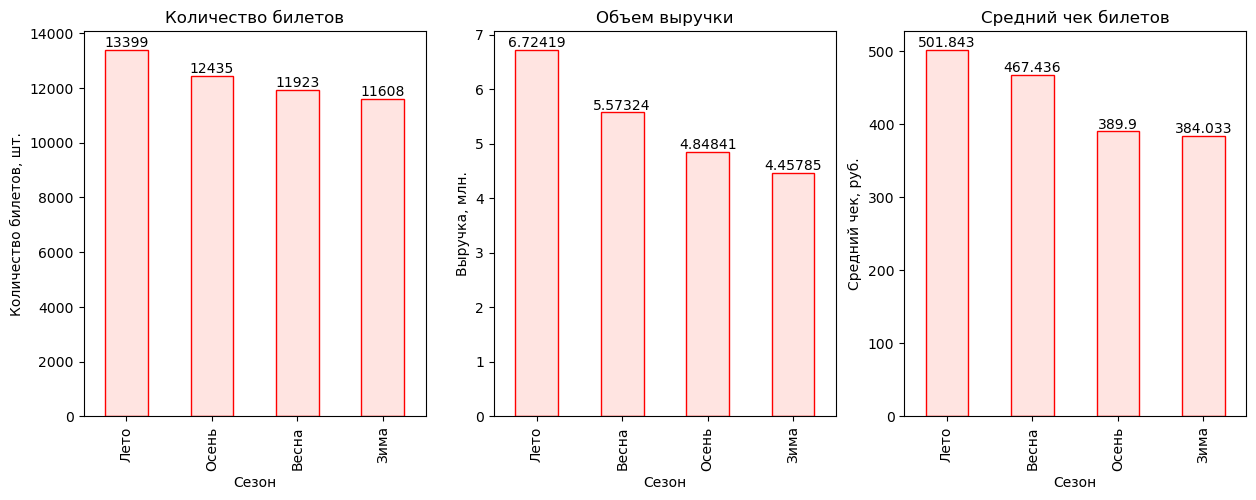

In [76]:
# Визуализация отчета 

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) # создаем сетку 1х3 для размещения графиков

# Создание отдельного графика для отображениия различий в количестве купленных билетов по сезонам
ax = season_df.sort_values(by='count_tickets', ascending=False).plot(kind='bar',
                                                                     x='issue_season',
                                                                     y='count_tickets',
                                                                     title='Количество билетов',
                                                                     xlabel='Сезон',
                                                                     ylabel='Количество билетов, шт.',
                                                                     color='mistyrose',
                                                                     edgecolor='red',
                                                                     legend=False,
                                                                     ax=axs[0]) # размещаем график в первой из трех созданных ячеек 

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

# Создание графика для отображения различий в общем объеме выручки, полученной от продажи билетов по сезонам
ax = season_df.sort_values(by='revenue', ascending=False).plot(kind='bar',
                                                               x='issue_season',
                                                               y='revenue',
                                                               title='Объем выручки',
                                                               xlabel='Сезон',
                                                               ylabel='Выручка, млн.',
                                                               color='mistyrose',
                                                               edgecolor='red',
                                                               legend=False,
                                                               ax=axs[1]) # размещаем график во второй из трех созданных ячеек 

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

# Создание графика для отображения различий в среднем чеке между билетами, купленными в разные сезоны
ax = season_df.sort_values(by='mean_revenue', ascending=False).plot(kind='bar',
                                                                    x='issue_season',
                                                                    y='mean_revenue',
                                                                    title='Средний чек билетов',
                                                                    xlabel='Сезон',
                                                                    ylabel='Средний чек, руб.',
                                                                    color='mistyrose',
                                                                    edgecolor='red',
                                                                    legend=False,
                                                                    ax=axs[2]) # размещаем график в третьей из трех созданных ячеек 

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

plt.show()

Представленный анализ позволяет выявить ключевые особенности зависимости выручки от сезона: 

1. Количественное преобладание билетов, купленных в летний период (27%), что обучловлено сезоном отпусков и каникул. Весна и осень стабильные сезоны с сопоставимым объемом продаж 24% и 25% соотвественно. Зимой количество проданных билетов составило 24%, что сопоставимо с продаже билетов весной, но по количеству зимой наблюдается спад продаж, что обусловлено поспадничным истощением и погодными факторами.
2. Выручка повторяет тренд продаж: лето также является периодом пика, а зима - периодом спада. Однако заметно значительное преобладание в объеме выручки весной в сравнении с объемом выручки зимой (5,5722 млн., что на 5% больше, чем выручка от продаж в зимний период (4,45785 млн.)), хотя в количественном соотношении наблюдается почти одинаковая ситуация (разница на 314 билетов в пользу весны).
3. Динамику подобную выручке повторяет динамика среднего чека, в которой весной средний чек на 5% выше чем осенью и зимой (467,388 против 389,9 и 384,033). Следовательно стоимость билетов весной дороже осенних и зимних авиабилетов. В среднем чеке осени и зимы наблюдается минимальное различие, более высокая выручка осенью объясняется большим количеством купленных в этот сезон билетов, так как осенью начинается сезон распродаж после летнего пика и увеличением доли эконом-сегмента в структуре продаж.

Весеннее удорожание билетов может быть вызвано актвиизацией бизнеса после зимнего спада: период активных командировок, заключения контрактов, увеличения количества совещаний, требующих вылета в офисы других городов и стран. 

In [77]:
# Перед проверкой гипотеза проверим распредление данных на нормальность

# Создаем отдельные датасеты для времени года (данные с выбросами)
autumn = df_new.query('issue_season == "Осень"')
winter = df_new.query('issue_season == "Зима"')

# Создаем отдельные датасеты для времени года (данные без выбросов)
autumn_1 = df_not_ejection.query('issue_season == "Осень"')
winter_1 = df_not_ejection.query('issue_season == "Зима"')

# Проверим количество наблюдений в каждом датасете 
print(f'Количество наблюдений в датасете "autumn" = {len(autumn)}')
print(f'Количество наблюдений в датасете "winter" = {len(winter)}')

Количество наблюдений в датасете "autumn" = 12435
Количество наблюдений в датасете "winter" = 11608


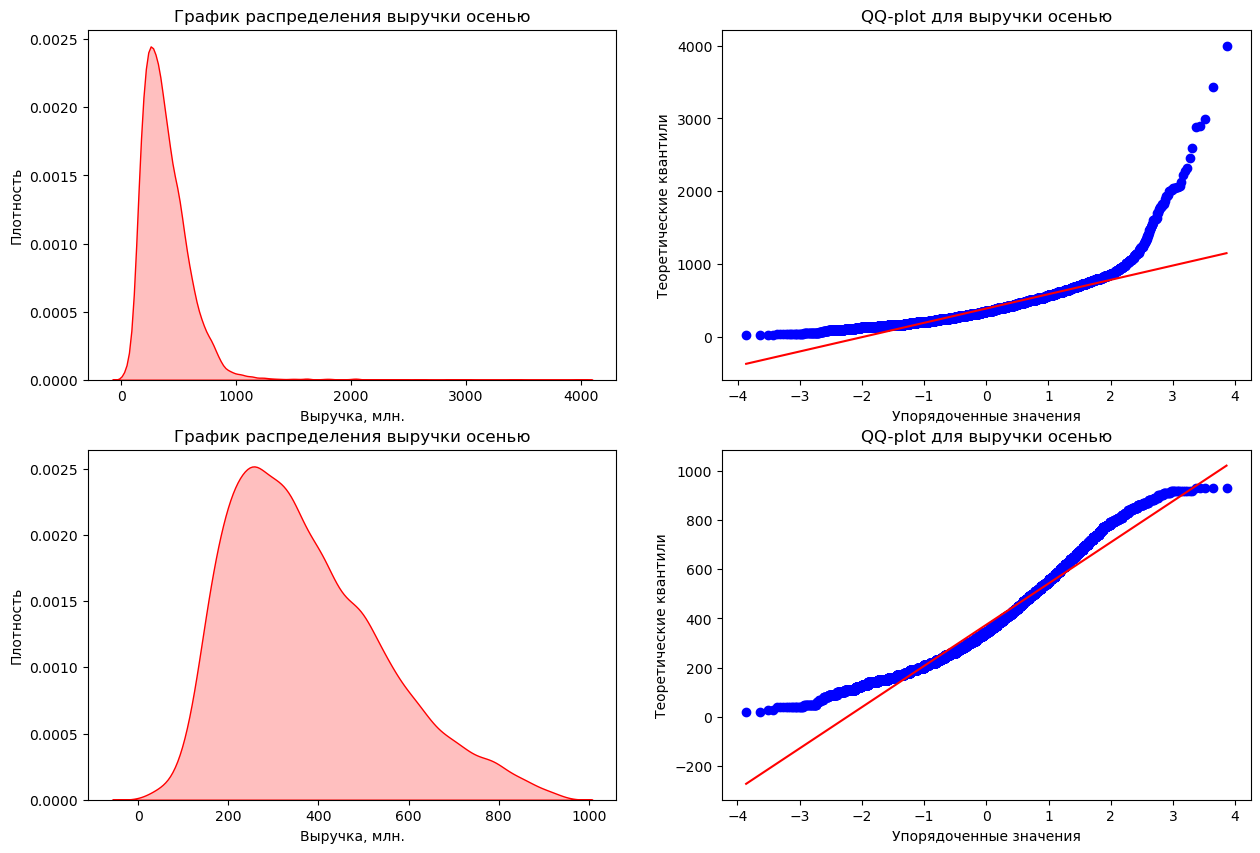

In [78]:
# Используем построение графиков распредления и Q-Q plot, так как применения теста Шапиро-Уилка плохо реализуется на больших данных 

# Построение графиков 
fig, axs = plt.subplots(2, 2, figsize=(15, 10)) # создаем сетку 2х2 для размещения графиков

# Осень (данные с выбросами)
# График плотности распредления 
sns.kdeplot(autumn['revenue_amount'], ax=axs[0, 0], color='red', fill='red').set(title='График распределения выручки осенью',
                                                                                 xlabel='Выручка, млн.',
                                                                                 ylabel='Плотность')
# QQ-plot
st.probplot(autumn['revenue_amount'], dist='norm', plot=axs[0, 1])
# Добавление подписей 
axs[0, 1].set_title('QQ-plot для выручки осенью')
axs[0, 1].set_ylabel('Теоретические квантили')
axs[0, 1].set_xlabel('Упорядоченные значения')

# Осень (данные без выбросов)
# График плотности распредления 
sns.kdeplot(autumn_1['revenue_amount'], ax=axs[1, 0], color='red', fill='red').set(title='График распределения выручки осенью',
                                                                                   xlabel='Выручка, млн.',
                                                                                   ylabel='Плотность')
# QQ-plot
st.probplot(autumn_1['revenue_amount'], dist='norm', plot=axs[1, 1])
# Добавление подписей 
axs[1, 1].set_title('QQ-plot для выручки осенью')
axs[1, 1].set_ylabel('Теоретические квантили')
axs[1, 1].set_xlabel('Упорядоченные значения')

plt.show()

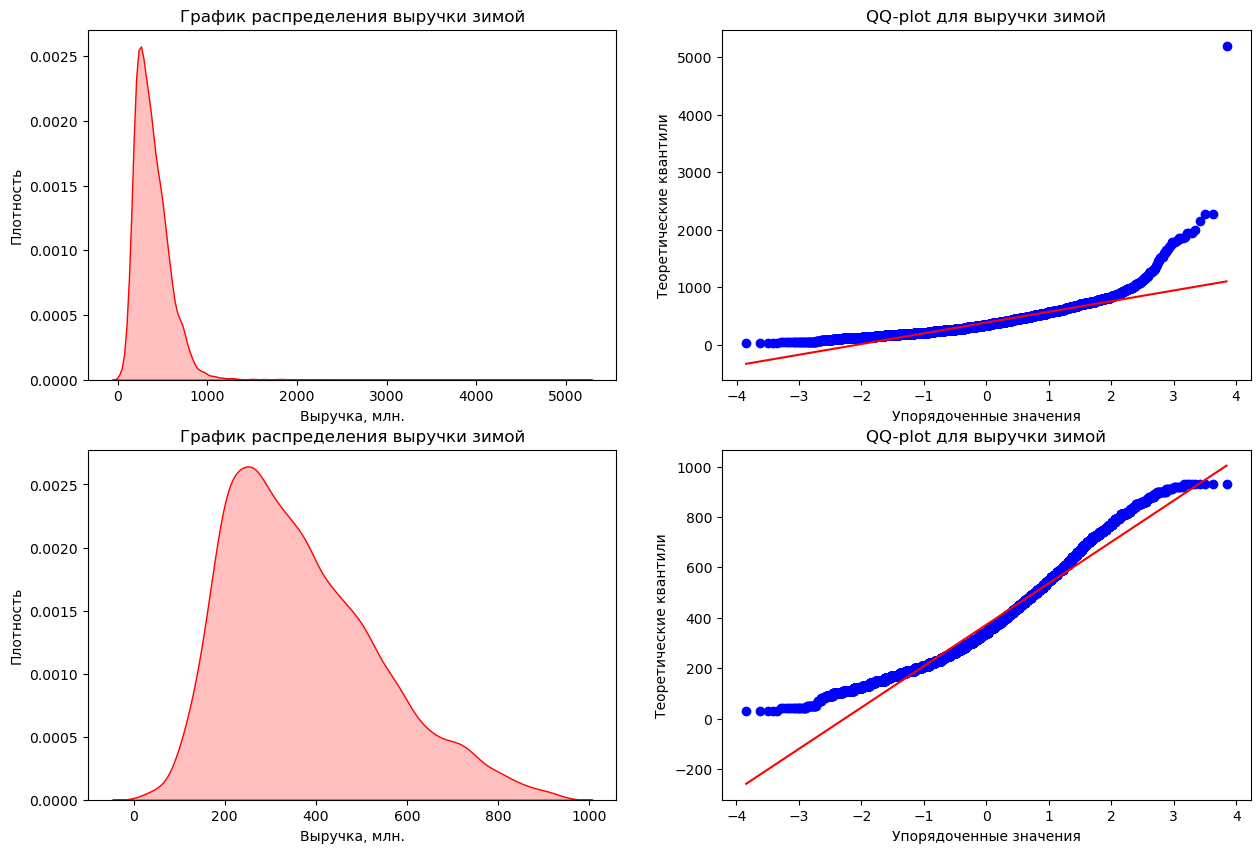

In [79]:
# Построение графиков 
fig, axs = plt.subplots(2, 2, figsize=(15, 10)) # создаем сетку 2х2 для размещения графиков

# Зима (данные с выбросами)
# График плотности распредления 
sns.kdeplot(winter['revenue_amount'], ax=axs[0, 0], color='red', fill='red').set(title='График распределения выручки зимой',
                                                                                 xlabel='Выручка, млн.',
                                                                                 ylabel='Плотность')
# QQ-plot
st.probplot(winter['revenue_amount'], dist='norm', plot=axs[0, 1])
# Добавление подписей 
axs[0, 1].set_title('QQ-plot для выручки зимой')
axs[0, 1].set_ylabel('Теоретические квантили')
axs[0, 1].set_xlabel('Упорядоченные значения')

# Осень (данные без выбросов)
# График плотности распредления 
sns.kdeplot(winter_1['revenue_amount'], ax=axs[1, 0], color='red', fill='red').set(title='График распределения выручки зимой',
                                                                                   xlabel='Выручка, млн.',
                                                                                   ylabel='Плотность')
# QQ-plot
st.probplot(winter_1['revenue_amount'], dist='norm', plot=axs[1, 1])
# Добавление подписей 
axs[1, 1].set_title('QQ-plot для выручки зимой')
axs[1, 1].set_ylabel('Теоретические квантили')
axs[1, 1].set_xlabel('Упорядоченные значения')

plt.show()

Таким образом, данные о выручке зимой и осенью распределены ненормально, что было доказано проведенными выше тестами.

Проведение тестов на нормальность распределения позволяет сделать вывод о том, что для проверки гипотезы целесообразно проводить и t-тест, и тест Манна-Уитни. Поскольку n > 30, можно использовать t-тест, но при явной ненормальности Манна-Уитни надежнее. Результаты обоих тестов дадут более полную и убедительную картину.

Тест Манна-Уитни будет проведен только на данных с выбросами, так как тест усточивый к выбросам, а t-тест будет проведен по обоим датасета.

In [80]:
# Проведем t-тест

alpha = 0.05 # уровень статистической значимости

# Н0: выручка осенью и зимой не различаются 
# Н1: выручка осенью и зимой различаются 

results = st.ttest_ind(autumn['revenue_amount'], winter['revenue_amount'], equal_var = False) # предполагаем неравенство дисперсий по совокупностям 

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу') 
else:
    print('Не удалось отвергнуть нулевую гипотезу') 

p-value: 0.029522105169960428
Следует отвергнуть нулевую гипотезу


In [81]:
# Проведем аналогичный тест для выборки без выбросов 

# Н0: выручка осенью и зимой не различаются 
# Н1: выручка осенью и зимой различаются 
 
results = st.ttest_ind(autumn_1['revenue_amount'], winter_1['revenue_amount'], equal_var = False) # предполагаем неравенство дисперсий по совокупностям 

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу') 
else:
    print('Не удалось отвергнуть нулевую гипотезу') 

p-value: 0.296180727615285
Не удалось отвергнуть нулевую гипотезу


In [82]:
# Проверка гипотезы о том, что выручка осенью и зимой различается 
alpha = 0.05

# Н0: выручка осенью и зимой не различаются 
# Н1: выручка осенью и зимой различаются 

# Создаем отдельные датасеты для времени года 
autumn = df_new.query('issue_season == "Осень"')
winter = df_new.query('issue_season == "Зима"')

# Проведем тест Манна-Уитни для сравнения двух независимых групп 
results = st.mannwhitneyu(autumn['revenue_amount'], winter['revenue_amount'])

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу') 
else:
    print('Не удалось отвергнуть нулевую гипотезу') 

p-value: 0.290916922864215
Не удалось отвергнуть нулевую гипотезу


Статистический анализ подтвердил, что различия в выручке между осенним и зимним сезонами являются статистически незначимыми. Это указывает на то, что осень и зиму нужно рассматривать как единый период низкой сезонности.

In [83]:
# Исследование выручки и число продаж по месяцам 

# список месяцев для дальнейшей сортировки по порядку месяцев в году 
month = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'] 

report_sales = df_new.pivot_table(index='issue_month', 
                                  aggfunc=[lambda x: x.sum() / 1_000_000, 'count'], # для удобства перевожу в миллионы  
                                  values='revenue_amount').reset_index().set_axis(['issue_month', 'revenue_(million)', 'count_tickets'], axis='columns').set_index('issue_month').loc[month].reset_index()

# set_index('issue_month').loc[month].reset_index() используется для преобразование индексов в месяцы, а затем для их сортировки в порядке, указанном 
# в списке month 

report_sales

,issue_month,revenue_(million),count_tickets
0,Январь,1.35239,3589
1,Февраль,1.34821,3454
2,Март,1.82643,4326
3,Апрель,2.03257,3974
4,Май,1.71424,3623
5,Июнь,1.61450,3353
6,Июль,2.63843,5259
7,Август,2.47126,4787
8,Сентябрь,1.66931,3648
9,Октябрь,1.32784,3615


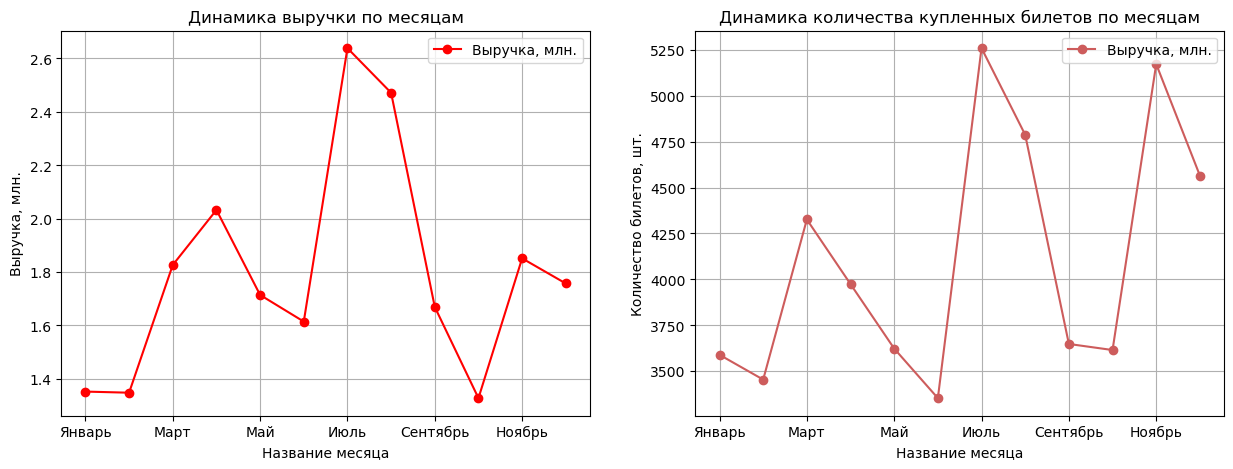

In [84]:
# Визуализация отчета 
fig, axs = plt.subplots(1, 2, figsize=(15, 5)) # создаем сетку 1х2 для размещения графиков

ax = report_sales.plot(x='issue_month', y='revenue_(million)',
                       title='Динамика выручки по месяцам',
                       xlabel='Название месяца',
                       ylabel='Выручка, млн.',
                       label='Выручка, млн.',
                       color='red',
                       style='o-',
                       grid=True, 
                       ax=axs[0]) # размещаем график в 1-й клетке сетки

ax = report_sales.plot(x='issue_month', y='count_tickets',
                       title='Динамика количества купленных билетов по месяцам',
                       xlabel='Название месяца',
                       ylabel='Количество билетов, шт.',
                       label='Выручка, млн.',
                       color='indianred',
                       style='o-',
                       grid=True, 
                       ax=axs[1]) # размещаем график во 2-й клетке сетки

plt.show()

Проанализиров получившиеся графики, было замечено несколько существенных различий: 

1. Апрель: по объему выручки значительно превышает март, хотя по количеству купленных билетов наблюдается противоположная ситуация. Данная тенденция может быть связана с существенной разницей в среднем чеке: средний чек за апрель самый высокий из всех месяцев.
2. Июнь: вырчука средняя, а количество купленных билетов минимальное, что может быть связано с увеличением числа покупок примеальным сегментом.
3. Октябрь: низкая выручка при относительно высоком количестве продаж, что может быть вызвано поптками компенсировать сезонный спад активной скидочной политикой 
4. Ноябрь: месяц пика в количестве купленных авиабилетов, что свидельствует об успешной промо-акции и раннем бронировании авиабилетов на новогодние праздники.

Таким образом, можно сказать, что существует взаимосвязь между объемом выручки и количеством купленных билетов. 

In [85]:
# Проверка корреляции между объемом выручки и количеством купленных билетов на данных с выбросами
kf = report_sales[['revenue_(million)', 'count_tickets']].corr()
kf 

,revenue_(million),count_tickets
revenue_(million),1.000000,0.777981
count_tickets,0.777981,1.000000


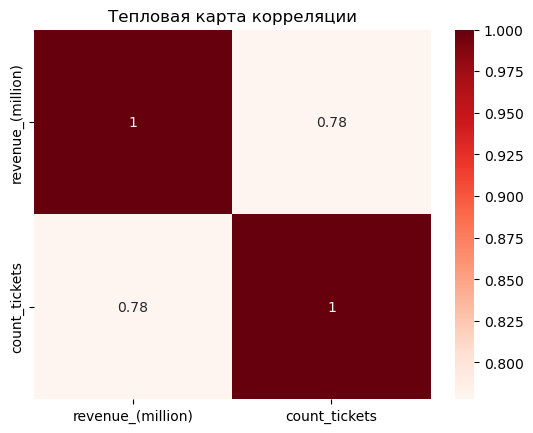

In [86]:
# Построим карту корреляции

sns.heatmap(kf, annot=True, cmap='Reds').set(title='Тепловая карта корреляции')
# cmap='Reds' - задание палитры
plt.show()

In [87]:
# Проверка корреляции между объемом выручки и количеством купленных билетов на данных без выбросов
report_sales_1 = df_not_ejection.pivot_table(index='issue_month', 
                                           aggfunc=[lambda x: x.sum() / 1_000_000, 'count'], # для удобства перевожу в миллионы  
                                           values='revenue_amount').reset_index().set_axis(['issue_month', 'revenue_(million)', 'count_tickets'],
                                                                                           axis='columns')

kf_1 = report_sales_1[['revenue_(million)', 'count_tickets']].corr()
kf_1 

,revenue_(million),count_tickets
revenue_(million),1.000000,0.752649
count_tickets,0.752649,1.000000


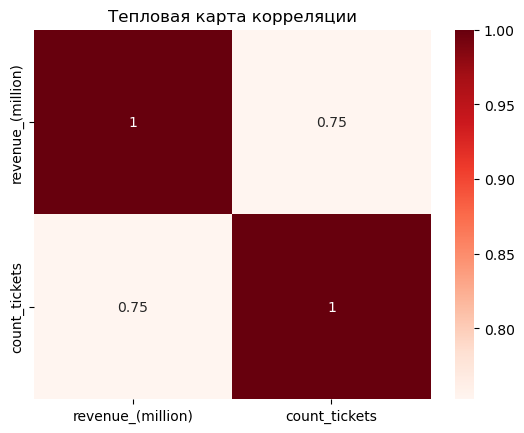

In [88]:
# Построим карту корреляции

sns.heatmap(kf_1, annot=True, cmap='Reds').set(title='Тепловая карта корреляции')
# cmap='Reds' - задание палитры
plt.show()

Таким образом, между объемом выручки и количеством купленных билетов существует высокая положительная корреляция (по шкале Чеддока) (r = 0.75)

<div class="alert alert-block alert-danger">

#### Вывод 

Таким образом, исследование сезонности продаж позволило сделать несколько ключевых выводов: 

1. Сезонность является ключевым фактором, влияющим на общий объем выручки и количество проданных билетов;
2. Осень и зиму следует рассматривать как единый низкий сезон: статистически значимых различий в выручке нет;
3. Между объемом выручки и количеством проданных билетов наблюдается высокая положительная корреляция, что подтверждает тесную прямую зависимость между этими метриками. Это фундаментальная основа бизнес-модели авиакомпании, где рост количества продаж является ключевым фактором роста выручки.

#### Задание 3.4

In [89]:
# Создадим в таблице отдельный столбец с разницей между днем покупки авиабилета и днем вылета 
df_new['count_days'] = (df_new['flight_date'] - df_new['issue_date']).dt.days

# Также добавляем столбец для данных без выбросов 
df_not_ejection['count_days'] = (df_not_ejection['flight_date'] - df_not_ejection['issue_date']).dt.days

df_new.head() # проверка

C:\Users\Алина\AppData\Local\Temp\ipykernel_20656\1973125765.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['count_days'] = (df_new['flight_date'] - df_new['issue_date']).dt.days
C:\Users\Алина\AppData\Local\Temp\ipykernel_20656\1973125765.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_not_ejection['count_days'] = (df_not_ejection['flight_date'] - df_not_ejection['issue_date']).dt.days


,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,issue_season,count_days
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,35
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь,Зима,3
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,Ноябрь,Осень,37
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,28
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021,Декабрь,Зима,35


Категоризием покупателей авиабилетов на 4 сегмента в зависимости от количества дней между покупкой билета и датой вылета: 

- 0-7 дней: покупка в последний момент;
- 8-30 дней: стандартная покупка;
- 31-90 дней: заблоговременная покупка;
- более чем за 91 день: очень ранняя покупка.

In [90]:
# Создадим функцию, которая позволит категоризировать клиентов 

def customer_category(count_days):

    if 0 <= count_days <= 7:
        return 'Покупка в последний момент'
    if 8 <= count_days <= 30:
        return 'Стандартная покупка'
    if 31 <= count_days <= 90:
        return 'Заблаговременная покупка'
    if 91 <= count_days:
        return 'Очень ранняя покупка'

In [91]:
# Создание столбца с категорией покупателей 

df_new['customer_category'] = df_new['count_days'].apply(customer_category)
df_not_ejection['customer_category'] = df_not_ejection['count_days'].apply(customer_category)

df_new.head() # проверка

C:\Users\Алина\AppData\Local\Temp\ipykernel_20656\934441381.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['customer_category'] = df_new['count_days'].apply(customer_category)
C:\Users\Алина\AppData\Local\Temp\ipykernel_20656\934441381.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_not_ejection['customer_category'] = df_not_ejection['count_days'].apply(customer_category)


,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,issue_season,count_days,customer_category
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,35,Заблаговременная покупка
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь,Зима,3,Покупка в последний момент
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,Ноябрь,Осень,37,Заблаговременная покупка
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,28,Стандартная покупка
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021,Декабрь,Зима,35,Заблаговременная покупка


In [92]:
# Для дальнейшего анализа удобно создать отедльные датасеты по категориям клиентов, для которых будет осуществлять проверка гипотезы

# По данным с выбросами 
last_moment = df_new.query('customer_category == "Покупка в последний момент"')
very_early = df_new.query('customer_category == "Очень ранняя покупка"')

# По данным без выбросов
last_moment_1 = df_not_ejection.query('customer_category == "Покупка в последний момент"')
very_early_1 = df_not_ejection.query('customer_category == "Очень ранняя покупка"')

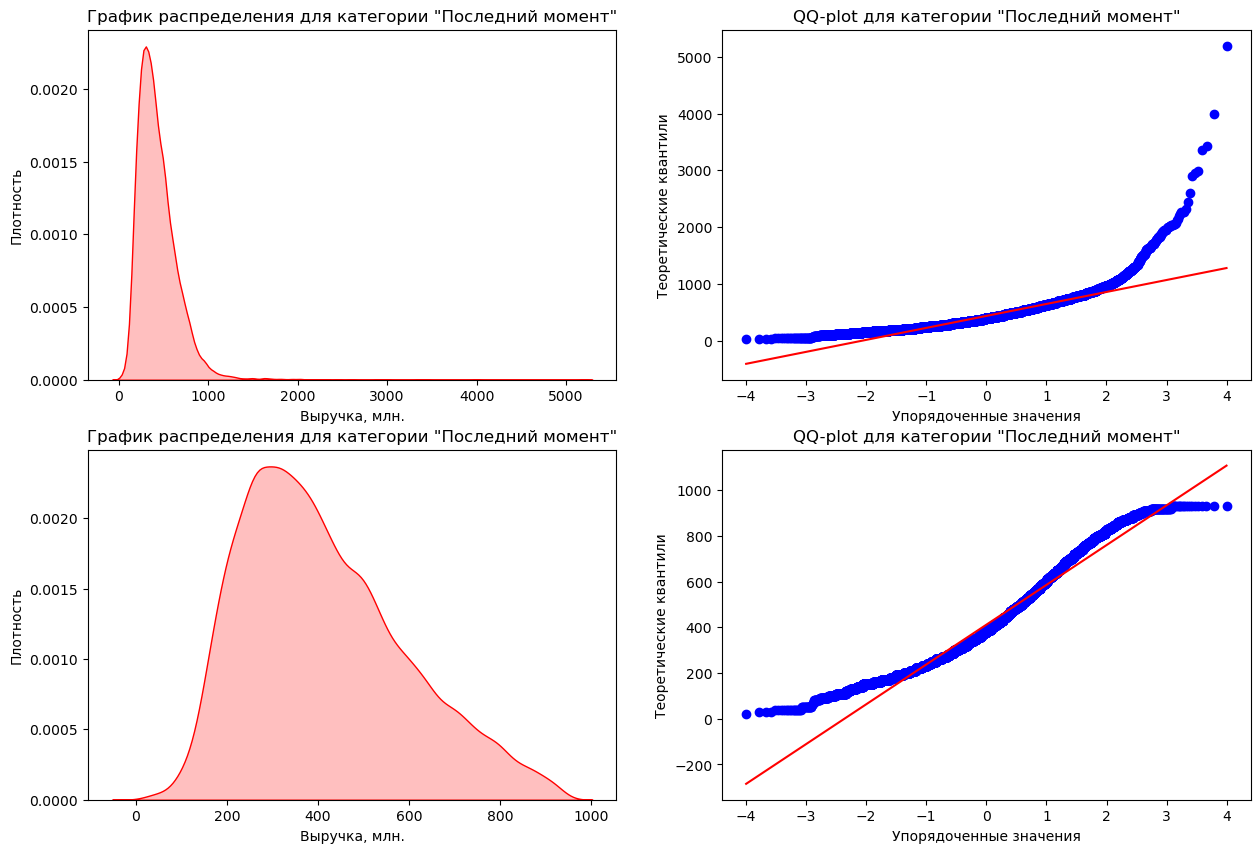

In [151]:
# Для проверки гипотез необходимо проверить, как распредлены данные по каждой категории клиентов
# Используем построение графиков распредления и Q-Q plot, так как применения теста Шапиро-Уилка плохо реализуется на больших данных 

# Построение графиков 
fig, axs = plt.subplots(2, 2, figsize=(15, 10)) # создаем сетку 4х2 для размещения графиков

# Категория "Последний момент" (данные с выбросами)
# График плотности распредления 
sns.kdeplot(last_moment['revenue_amount'], ax=axs[0, 0], color='red', fill='red').set(title='График распределения для категории "Последний момент"',
                                                                                      xlabel='Выручка, млн.',
                                                                                      ylabel='Плотность')
# QQ-plot
st.probplot(last_moment['revenue_amount'], dist='norm', plot=axs[0, 1])
# Добавление подписей 
axs[0, 1].set_title('QQ-plot для категории "Последний момент"')
axs[0, 1].set_ylabel('Теоретические квантили')
axs[0, 1].set_xlabel('Упорядоченные значения')

# Категория "Последний момент" (данные без выбросов)
# График плотности распредления 
sns.kdeplot(last_moment_1['revenue_amount'], ax=axs[1, 0], color='red', fill='red').set(title='График распределения для категории "Последний момент"',
                                                                                        xlabel='Выручка, млн.',
                                                                                        ylabel='Плотность')
# QQ-plot
st.probplot(last_moment_1['revenue_amount'], dist='norm', plot=axs[1, 1])
# Добавление подписей 
axs[1, 1].set_title('QQ-plot для категории "Последний момент"')
axs[1, 1].set_ylabel('Теоретические квантили')
axs[1, 1].set_xlabel('Упорядоченные значения')

plt.show()

Таким образом, выручка по категории клиентов, покупающих билеты в последний момент распредлена ненормально: сильный правый хвост, распредление скошено влево (левостороняя ассиметрия), точки сильно отклоняются от прямой линии, в хвостах распределения наблюдается значительное расхождение.

Проверка нормально распредления на данных, очищенных от выбросов, показала тот же результат: данные распределены ненормально.

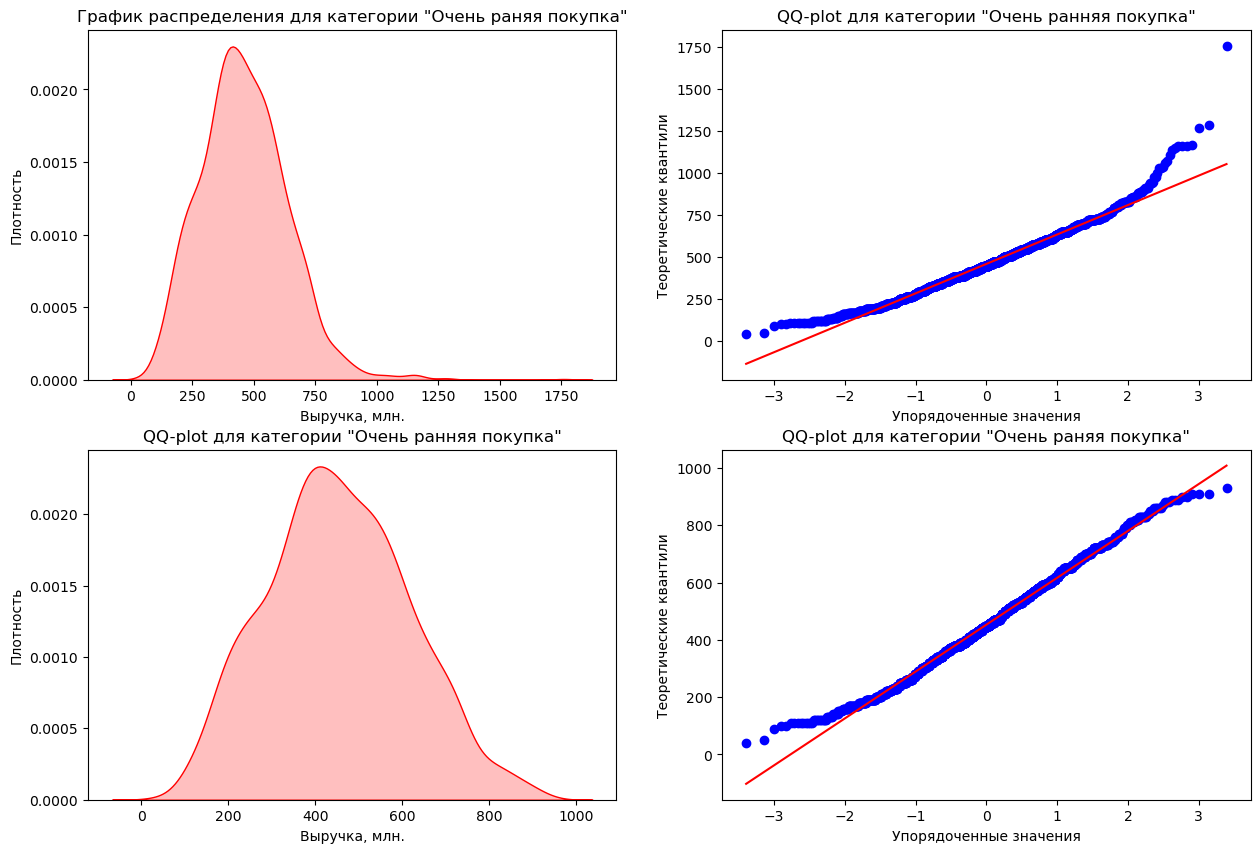

In [152]:
# Построение графиков 
fig, axs = plt.subplots(2, 2, figsize=(15, 10)) # создаем сетку 4х2 для размещения графиков

# Категория "Очень раняя покупка" (данные с выбросами)
# График плотности распредления 
sns.kdeplot(very_early['revenue_amount'], ax=axs[0, 0], color='red', fill='red').set(title='График распределения для категории "Очень раняя покупка"',
                                                                                     xlabel='Выручка, млн.',
                                                                                     ylabel='Плотность')
# QQ-plot
st.probplot(very_early['revenue_amount'], dist='norm', plot=axs[0, 1])
# Добавление подписей 
axs[0, 1].set_title('QQ-plot для категории "Очень ранняя покупка"')
axs[0, 1].set_ylabel('Теоретические квантили')
axs[0, 1].set_xlabel('Упорядоченные значения')

# Категория "Последний момент" (данные без выбросов)
# График плотности распредления 
sns.kdeplot(very_early_1['revenue_amount'], ax=axs[1, 0], color='red', fill='red').set(title='QQ-plot для категории "Очень ранняя покупка"',
                                                                                       xlabel='Выручка, млн.',
                                                                                       ylabel='Плотность')
# QQ-plot
st.probplot(very_early_1['revenue_amount'], dist='norm', plot=axs[1, 1])
# Добавление подписей 
axs[1, 1].set_title('QQ-plot для категории "Очень раняя покупка"')
axs[1, 1].set_ylabel('Теоретические квантили')
axs[1, 1].set_xlabel('Упорядоченные значения')

plt.show()

In [95]:
# Распределение клиентов  по категории "Очень раняя покупка" очень похоже на нормальное. Данная категория содержит менее 5 тысяч наблюдений
# Целесообразно провести тест Шапиро-Уилка

# Н0: данные по категории "Очень ранняя покупка" распредлены нормально 
# Н1: данные по категории "Очень ранняя покупка" распределены ненормально

# тест Шапиро-Уилка (для данных с выбросами)
stat, p = st.shapiro(very_early['revenue_amount'])

alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка НЕ имеет нормального распределения')
else:
    print(p, 'Не получилось отвергнуть нулевую гипотезу. Выборка имеет нормальное распределение')

8.974732102121705e-19 Отвергаем нулевую гипотезу. Выборка НЕ имеет нормального распределения


In [96]:
# тест Шапиро-Уилка (для данных без выбросов)
stat, p = st.shapiro(very_early_1['revenue_amount'])

alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка НЕ имеет нормального распределения')
else:
    print(p, 'Не получилось отвергнуть нулевую гипотезу. Выборка имеет нормальное распределение')

4.7568676375625525e-08 Отвергаем нулевую гипотезу. Выборка НЕ имеет нормального распределения


Таким образом, данные по категории "Очень ранняя покупка" распределены ненормально, что было доказано проведением теста Шапиро-Уилка.

Проведение тестов на нормальность распределения позволяет сделать вывод о том, что для проверки гипотезы целесообразно проводить и t-тест, и тест Манна-Уитни. Поскольку n > 30, можно использовать t-тест, но при явной ненормальности Манна-Уитни надежнее. Результаты обоих тестов дадут более полную и убедительную картину.

Тест Манна-Уитни будет проведен только на данных с выбросами, так как тест усточивый к выбросам, а t-тест будет проведен по обоим датасета.

In [97]:
# Проверка гипотезы о том, что выручка по клиентам, покупающим билеты в последний момент и покупающих билеты очень заранее отличается 
# Тест Манна-Уитни 

# Н0: выручка по клиентам, покупающим билеты в последний момент и покупающих билеты очень заранее не отличается
# Н1: выручка по клиентам, покупающим билеты в последний момент и покупающих билеты очень заранее отличается

alpha = 0.05 # уровень статистической значимости

results = st.mannwhitneyu(last_moment['revenue_amount'], very_early['revenue_amount'])

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу') 
else:
    print('Не удалось отвергнуть нулевую гипотезу') 

p-value: 4.908502448190464e-26
Следует отвергнуть нулевую гипотезу


In [162]:
# t-тест (с выбросами)

# Н0: средняя выручка по клиентам, покупающим билеты в последний момент и покупающих билеты очень заранее не отличается
# Н1: средняя выручка по клиентам, покупающим билеты в последний момент и покупающих билеты очень заранее отличается

alpha = 0.05 # уровень статистической значимости

results = st.ttest_ind(last_moment['revenue_amount'], very_early['revenue_amount'], equal_var=False)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу') 
else:
    print('Не удалось отвергнуть нулевую гипотезу') 

p-value: 7.52695430776111e-10
Следует отвергнуть нулевую гипотезу


In [165]:
# t-тест (без выбросов)

# Н0: средняя выручка по клиентам, покупающим билеты в последний момент и покупающих билеты очень заранее не отличается
# Н1: средняя выручка по клиентам, покупающим билеты в последний момент и покупающих билеты очень заранее отличается

alpha = 0.05 # уровень статистической значимости

results = st.ttest_ind(last_moment_1['revenue_amount'], very_early_1['revenue_amount'], equal_var=False)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Следует отвергнуть нулевую гипотезу') 
else:
    print('Не удалось отвергнуть нулевую гипотезу') 

p-value: 6.872535863056304e-26
Следует отвергнуть нулевую гипотезу


<div class="alert alert-block alert-danger">

#### Вывод 

Статистически подтверждено, что время покупки авиабилета является значимым фактором, определяющим формирование выручки. Клиенты, приобретающие билеты в последний момент (0-7 дней до вылета), платят больше по сравнению с теми, кто покупает билеты очень заранее (>90 дней). Данный вывод подтверждают проведенные статистические тесты (t-тест с выбросами, t-тест без выбросов, тест Манна-Уитни) и предварительное проведение анализа распределения, который выявил различную природу данных в сравниваемых группах. 

Это свидетельствует об эффективности применяемой авиакомпанией стратегии динамического ценообразования, при которой стоимость билетов закономерно возрастает по мере приближения даты вылета, максимизируя доходность от клиентов с неэластичным спросом (клиентов, покупающих билеты в последний момент)

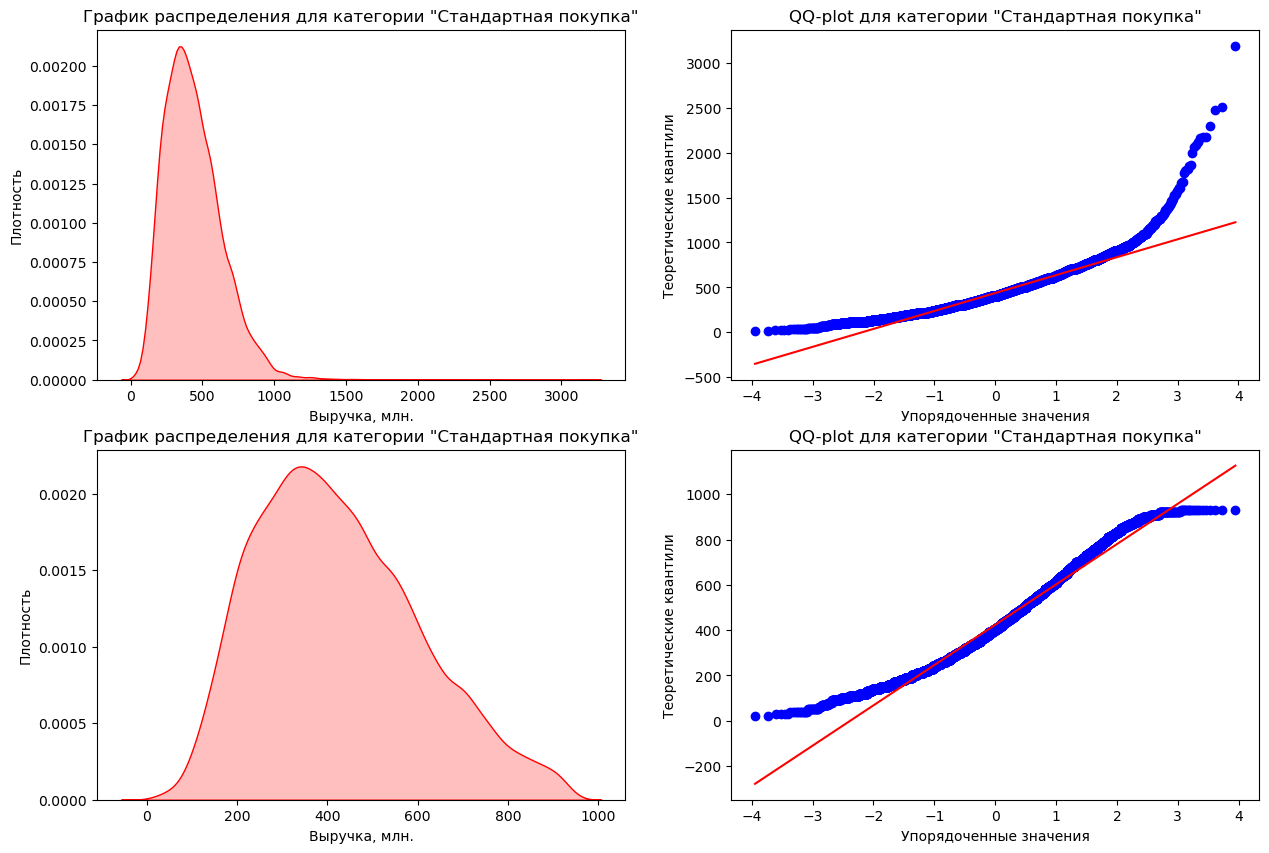

In [153]:
# Дополнительно рассмотрим различие в величине выручки по всем выделенным категориям 

# Для дальнейшего анализа удобно создать отедльные датасеты по категориям клиентов, для которых будет осуществлять проверка гипотезы

# По данным с выбросами 
standart = df_new.query('customer_category == "Стандартная покупка"')
early = df_new.query('customer_category == "Заблаговременная покупка"')

# По данным без выбросов
standart_1 = df_not_ejection.query('customer_category == "Стандартная покупка"')
early_1 = df_not_ejection.query('customer_category == "Заблаговременная покупка"')

# Для проверки гипотез необходимо проверить, как распредлены данные по каждой категории клиентов
# Используем построение графиков распредления и Q-Q plot, так как применения теста Шапиро-Уилка плохо реализуется на больших данных 

# Построение графиков 
fig, axs = plt.subplots(2, 2, figsize=(15, 10)) # создаем сетку 4х2 для размещения графиков

# Категория "Стандартная покупка" (данные с выбросами)
# График плотности распредления 
sns.kdeplot(standart['revenue_amount'], ax=axs[0, 0], color='red', fill='red').set(title='График распределения для категории "Стандартная покупка"',
                                                                                   xlabel='Выручка, млн.',
                                                                                   ylabel='Плотность')
# QQ-plot
st.probplot(standart['revenue_amount'], dist='norm', plot=axs[0, 1])
# Добавление подписей 
axs[0, 1].set_title('QQ-plot для категории "Стандартная покупка"')
axs[0, 1].set_ylabel('Теоретические квантили')
axs[0, 1].set_xlabel('Упорядоченные значения')

# Категория "Стандартная покупка" (данные без выбросов)
# График плотности распредления 
sns.kdeplot(standart_1['revenue_amount'], ax=axs[1, 0], color='red', fill='red').set(title='График распределения для категории "Стандартная покупка"',
                                                                                     xlabel='Выручка, млн.',
                                                                                     ylabel='Плотность')
# QQ-plot
st.probplot(standart_1['revenue_amount'], dist='norm', plot=axs[1, 1])
# Добавление подписей 
axs[1, 1].set_title('QQ-plot для категории "Стандартная покупка"')
axs[1, 1].set_ylabel('Теоретические квантили')
axs[1, 1].set_xlabel('Упорядоченные значения')

plt.show()

Таким образом, выручка по категории клиентов, покупающих билеты в стандартное время распредлена ненормально.

Проверка нормально распредления на данных, очищенных от выбросов, показала тот же результат: данные распределены ненормально.

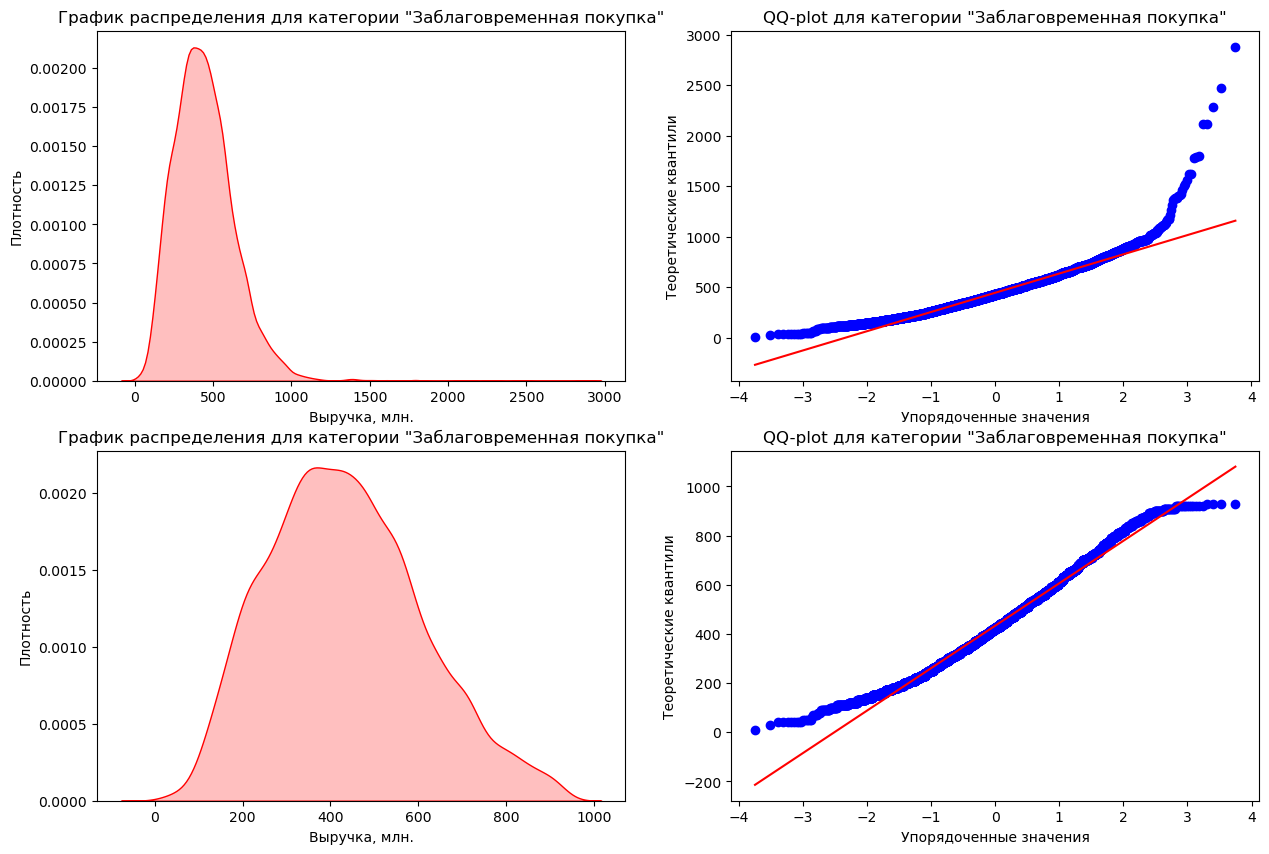

In [154]:
# Построение графиков 
fig, axs = plt.subplots(2, 2, figsize=(15, 10)) # создаем сетку 4х2 для размещения графиков

# Категория "Заблаговременная покупка" (данные с выбросами)
# График плотности распредления 
sns.kdeplot(early['revenue_amount'], ax=axs[0, 0], color='red', fill='red').set(title='График распределения для категории "Заблаговременная покупка"',
                                                                                xlabel='Выручка, млн.',
                                                                                ylabel='Плотность')
# QQ-plot
st.probplot(early['revenue_amount'], dist='norm', plot=axs[0, 1])
# Добавление подписей 
axs[0, 1].set_title('QQ-plot для категории "Заблаговременная покупка"')
axs[0, 1].set_ylabel('Теоретические квантили')
axs[0, 1].set_xlabel('Упорядоченные значения')

# Категория "Заблаговременная покупка" (данные без выбросов)
# График плотности распредления 
sns.kdeplot(early_1['revenue_amount'], ax=axs[1, 0], color='red', fill='red').set(title='График распределения для категории "Заблаговременная покупка"',
                                                                                  xlabel='Выручка, млн.',
                                                                                  ylabel='Плотность')
# QQ-plot
st.probplot(early_1['revenue_amount'], dist='norm', plot=axs[1, 1])
# Добавление подписей 
axs[1, 1].set_title('QQ-plot для категории "Заблаговременная покупка"')
axs[1, 1].set_ylabel('Теоретические квантили')
axs[1, 1].set_xlabel('Упорядоченные значения')

plt.show()

Таким образом, выручка по категории клиентов, покупающих билеты заблаговременно распредлены ненормально.

Проверка нормально распредления на данных, очищенных от выбросов, показала тот же результат: данные распределены ненормально.

Проведем тест с поправкой на множественную проверку гипотез (порог Холма) с использованием теста Манна-Уитни, так как данные распределены ненормально, использую датасет с выбросами, так как тест устойчив к ним.

In [157]:
# Вводим гипотезы: 

1.
# Н0: Выручка от продажи билетов клиентам по категории "последний момент" и "стандартная покупка" не отличаются
# Н1: Выручка от продажи билетов клиентам по категории "последний момент" и "стандартная покупка" отличаются

2.
# Н0: Выручка от продажи билетов клиентам по категории "последний момент" и "заблаговременная покупка" не отличаются
# Н1: выручка от продажи билетов клиентам по категории "последний момент" и "заблаговременная покупка" отличаются

3.
# Н0: Выручка от продажи билетов клиентам по категории "последний момент" и "очень ранняя покупка" не отличаются
# Н1: выручка от продажи билетов клиентам по категории "последний момент" и "очень ранняя покупка" отличаются

4.
# Н0: Выручка от продажи билетов клиентам по категории "стандартная покупка" и "заблаговременная покупка" не отличаются
# Н1: Выручка от продажи билетов клиентам по категории "стандартная покупка" и "заблаговременная покупка" отличаются

5.
# Н0: Выручка от продажи билетов клиентам по категории "стандартная покупка" и "очень ранняя покупка" не отличаются
# Н1: Выручка от продажи билетов клиентам по категории "стандартная покупка" и "очень ранняя покупка" отличаются

6.
# НО: Выручка от продажи билетов клиентам по категории "заблаговременная покупка" и "очень ранняя покупка" не отличаются
# Н1: Выручка от продажи билетов клиентам по категории "заблаговременная покупка" и "очень ранняя покупка" отличаются 

# 1. Рассчитываем pvalue для каждой гипотезы
p_value = []
a = [last_moment, last_moment, last_moment, standart, standart, early] # вспомогательные списки 
b = [standart, early, very_early, early, very_early, very_early]

for i, j in zip(a, b):
    results = st.mannwhitneyu(i['revenue_amount'], j['revenue_amount'])
    pvalue = results.pvalue
    p_value.append(pvalue) # список, содержащий значение p_value по всем гипотезам 

# Для удобства создаю датафрейм 
df_pvalue = pd.DataFrame(data=p_value, index=[1, 2, 3, 4, 5, 6]).reset_index().set_axis(['hp_number', 'pvalue'],
                                                                                         axis='columns')
# индекс - номер гипотезы 

# 2. Упорядочить по p_value
df_pvalue = df_pvalue.sort_values(by='pvalue')

# 3. Считаем порог Холма 
n = 6 # количество гипотез 
df_pvalue['hill_threshold'] = alpha / (n - df_pvalue['hp_number'] + 1)

# 4. Сравниваем pvalue с порогом Холма, получая незначимый результат, остальные тесты не проверяются 
def test(pvalue, hill):

    if pvalue < hill:
        return 'Н0 отвергается'

# Применение функции 
df_pvalue['check_hp'] = df_pvalue.apply(lambda x: test(x['pvalue'], x['hill_threshold']), axis=1)

# Выводим результат 
df_pvalue 

,hp_number,pvalue,hill_threshold,check_hp
2,3,4.908502e-26,0.012500,Н0 отвергается
1,2,3.963797e-21,0.010000,Н0 отвергается
4,5,2.628850e-14,0.025000,Н0 отвергается
0,1,8.382078e-10,0.008333,Н0 отвергается
5,6,9.254454e-07,0.050000,Н0 отвергается
3,4,1.254537e-05,0.016667,Н0 отвергается


<div class="alert alert-block alert-danger">

#### Вывод: 

Таким образом, проведенный тест показал, что каждая из 4 выделенных категорий клиентов имеет статистически значимые различия в величине выручки, следовательно, время покупки авиабилета является значимым фактором, определяющим формирование выручки.

#### Задание 3.5 

In [100]:
# Ранее таблица с дополнительными данными уже выводилась 
df_airport.head()

# Изменим названия обратно на прежние
column_names = ['Index', 'Airport Name', 'Location', 'Country', 'IATA_Code', 'ICAO_Code', 'Latitude', 'Longitude', 'Altitude', 'Timezone', 'DST', 'Timezone Region', 'Type', 'Source']
df_airport.columns = column_names
df_airport.columns = df_airport.columns.str.lower() # переведем названия в нижний регистр

df_airport.head() # проверка 

,index,airport name,location,country,iata_code,icao_code,latitude,longitude,altitude,timezone,dst,timezone region,type,source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports


In [101]:
len(df_new)

49365

In [102]:
# Добавим в исходный датасет сведения о городах с помощью функции merge по столбцу с кодом пункта отправления и прибытия  

# Сначала присоедим названия городов для пунктов отправления. Для этого необходимо, чтобы столбец с кодом аэропорта в обеих таблицах совпадал
df_airport = df_airport.rename(columns={'iata_code': 'departure_city_code'})	

# Добавим в таблицу названия городов отправления 
df_new = df_new.merge(df_airport[['departure_city_code', 'location']], on='departure_city_code', how='left')

# Переменуем добавленные столбцы 
df_new = df_new.rename(columns={'location': 'departure_city_name'})

len(df_new)

49365

In [103]:
df_new.head()

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,issue_season,count_days,customer_category,departure_city_name
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,35,Заблаговременная покупка,NaN
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь,Зима,3,Покупка в последний момент,Yuzhno-sakhalinsk
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,Ноябрь,Осень,37,Заблаговременная покупка,Kaliningrad
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,28,Стандартная покупка,Voronezh
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021,Декабрь,Зима,35,Заблаговременная покупка,NaN


In [104]:
# По проверке таблицы видно, что в некоторых местах возникли пропуски 

df_new['departure_city_name'].isna().sum()

np.int64(16188)

In [105]:
# Посмотри пропущенные значения 
skip = df_new[['departure_city_code', 'departure_city_name']][df_new['departure_city_name'].isna()]
skip

,departure_city_code,departure_city_name
0,MOW,NaN
4,MOW,NaN
5,MOW,NaN
6,MOW,NaN
7,MOW,NaN
...,...,...
49346,MOW,NaN
49356,MOW,NaN
49357,MOW,NaN
49360,MOW,NaN


In [106]:
# Проверим, по одному ли коду пропущены значения
skip['departure_city_code'].unique()	

array(['MOW', 'PAR', 'BAK', 'ROM', 'SEL', 'BER', 'GRV', 'NQZ', 'OHH',
       'TOX', 'MIL', 'TYO', 'LON'], dtype=object)

Необходимо установить, каким городам прирнадлежат данные коды. 

- 'MOW' - Москва;
- 'PAR' - Париж;
- 'BAK' - Баку;
- 'ROM' - Рим;
- 'SEL' - Сеул;
- 'BER' - Берлин 
- 'GRV' - Грозный;
- 'NQZ' - Астана;
- 'OHH' - Оха;
- 'TOX' - Толольск;
- 'MIL' - Милан;
- 'TYO' - Токио; 
- 'LON' - Лондон.

In [107]:
df_dop = df_airport[['departure_city_code', 'location']] # создадим дополнительную таблицу, которая содержит только код города и его нразвания
df_dop.head() # проверка

,departure_city_code,location
0,GKA,Goroka
1,MAG,Madang
2,HGU,Mount Hagen
3,LAE,Nadzab
4,POM,Port Moresby


In [108]:
# Создаем словарь пропущенных значений
skip_dict = {'departure_city_code': ['MOW', 'PAR', 'BAK', 'ROM', 'SEL', 'BER', 'GRV', 'NQZ', 'OHH', 'TOX', 'MIL', 'TYO', 'LON'],
             'location': ['Moscow', 'Paris', 'Baku', 'Rome', 'Seoul', 'Berlin', 'Grozny', 'Astana', 'Okha', 'Tobolsk', 
                          'Milan', 'Tokyo', 'London']}

In [109]:
# Оформляем словарь в даатфрейм 
df_skip = pd.DataFrame(data=skip_dict)
df_skip

,departure_city_code,location
0,MOW,Moscow
1,PAR,Paris
2,BAK,Baku
3,ROM,Rome
4,SEL,Seoul
5,BER,Berlin
6,GRV,Grozny
7,NQZ,Astana
8,OHH,Okha
9,TOX,Tobolsk


In [110]:
df_merge = pd.concat([df_dop, df_skip]) # создаем новый даатфрейм для присоединения нгазваний городов 

In [111]:
# Удалим ранее присоединенный столбец 
df_new = df_new.drop(axis=1, columns='departure_city_name')

In [112]:
# Присоединяем столбец с названиями городов отправления, используя новый датафрейм 
df_new = df_new.merge(df_merge, on='departure_city_code', how='left')

# Переменуем добавленные столбцы 
df_new = df_new.rename(columns={'location': 'departure_city_name'})

df_new.head() # проверка

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,issue_season,count_days,customer_category,departure_city_name
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,35,Заблаговременная покупка,Moscow
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь,Зима,3,Покупка в последний момент,Yuzhno-sakhalinsk
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,Ноябрь,Осень,37,Заблаговременная покупка,Kaliningrad
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,28,Стандартная покупка,Voronezh
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021,Декабрь,Зима,35,Заблаговременная покупка,Moscow


In [113]:
# Проверка пропусков 
df_new['departure_city_name'].isna().sum()

np.int64(0)

In [114]:
# Присоединим названия городов отправления к данным без выбросов 
df_not_ejection = df_not_ejection.merge(df_merge, on='departure_city_code', how='left')

# Переменуем добавленные столбцы 
df_not_ejection = df_not_ejection.rename(columns={'location': 'departure_city_name'})

df_not_ejection.head() # проверка

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,issue_season,count_days,customer_category,departure_city_name
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,35,Заблаговременная покупка,Moscow
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь,Зима,3,Покупка в последний момент,Yuzhno-sakhalinsk
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,Ноябрь,Осень,37,Заблаговременная покупка,Kaliningrad
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,28,Стандартная покупка,Voronezh
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021,Декабрь,Зима,35,Заблаговременная покупка,Moscow


In [115]:
# Добавим названия городов прибытия 

# Для этого необходимо, чтобы столбец с кодом аэропорта в обеих таблицах совпадал
df_merge = df_merge.rename(columns={'departure_city_code': 'dest_city_code'})	

# Добавим в таблицу названия городов отправления 
df_new = df_new.merge(df_merge, on='dest_city_code', how='left')

# Переменуем добавленные столбцы 
df_new = df_new.rename(columns={'location': 'dest_city_name'})

df_new.head() # проверка

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,issue_season,count_days,customer_category,departure_city_name,dest_city_name
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,35,Заблаговременная покупка,Moscow,Kaliningrad
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь,Зима,3,Покупка в последний момент,Yuzhno-sakhalinsk,Novosibirsk
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,Ноябрь,Осень,37,Заблаговременная покупка,Kaliningrad,Moscow
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,28,Стандартная покупка,Voronezh,Moscow
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021,Декабрь,Зима,35,Заблаговременная покупка,Moscow,Krasnodar


In [116]:
# Присоединим названия городов прибытия к данным без выбросов 
df_not_ejection = df_not_ejection.merge(df_merge, on='dest_city_code', how='left')

# Переменуем добавленные столбцы 
df_not_ejection = df_not_ejection.rename(columns={'location': 'dest_city_name'})

df_not_ejection.head() # проверка

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,issue_season,count_days,customer_category,departure_city_name,dest_city_name
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,35,Заблаговременная покупка,Moscow,Kaliningrad
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь,Зима,3,Покупка в последний момент,Yuzhno-sakhalinsk,Novosibirsk
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,Ноябрь,Осень,37,Заблаговременная покупка,Kaliningrad,Moscow
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,28,Стандартная покупка,Voronezh,Moscow
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021,Декабрь,Зима,35,Заблаговременная покупка,Moscow,Krasnodar


In [117]:
# Для удоства создаю отдельный столбец, объединяющий города отправления и прибытия
df_new['city-city'] = df_new['departure_city_name'] + '-' + df_new['dest_city_name']
df_new.head()

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,issue_season,count_days,customer_category,departure_city_name,dest_city_name,city-city
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,35,Заблаговременная покупка,Moscow,Kaliningrad,Moscow-Kaliningrad
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NOT_FFP,OFFLINE,2021,Декабрь,Зима,3,Покупка в последний момент,Yuzhno-sakhalinsk,Novosibirsk,Yuzhno-sakhalinsk-Novosibirsk
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,Ноябрь,Осень,37,Заблаговременная покупка,Kaliningrad,Moscow,Kaliningrad-Moscow
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NOT_FFP,ONLINE,2021,Декабрь,Зима,28,Стандартная покупка,Voronezh,Moscow,Voronezh-Moscow
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021,Декабрь,Зима,35,Заблаговременная покупка,Moscow,Krasnodar,Moscow-Krasnodar


In [118]:
# Определим топ-10 популярных направлений перелета (город-город) отдельно для ВВЛ
# Для опредление топ-10 популряных направлений буду использовать количество купленных билетов

# Создадим отдельный датасет, содержащий информацию только о перелетах ВВЛ 
df_vvl = df_new.query('route_flight_type == "ВВЛ"')
report_vvl = df_vvl.pivot_table(index='city-city',
                                aggfunc=['count', lambda x: round(x.mean(), 3), lambda x: x.sum() / 1_000_000],
                                values='revenue_amount').reset_index().set_axis(['route', 'count_tickets', 'mean_revenue', 'revenue_(million)'], 
                                                                                axis='columns').sort_values(by='count_tickets', ascending=False)

top_10_route_vvl = report_vvl.head(10)
top_10_route_vvl

,route,count_tickets,mean_revenue,revenue_(million)
266,Sochi-Moscow,1341,398.606,0.53453
143,Moscow-Sochi,1309,382.559,0.50077
271,St. Petersburg-Moscow,1212,232.764,0.28211
144,Moscow-St. Petersburg,1192,231.367,0.27579
201,Novosibirsk-Moscow,972,481.008,0.46754
130,Moscow-Novosibirsk,956,481.224,0.46005
55,Kazan-Moscow,760,271.566,0.20639
112,Moscow-Kazan,758,271.715,0.20596
148,Moscow-Ufa,708,297.472,0.21061
218,Novosibirsk-Sochi,695,595.252,0.41370


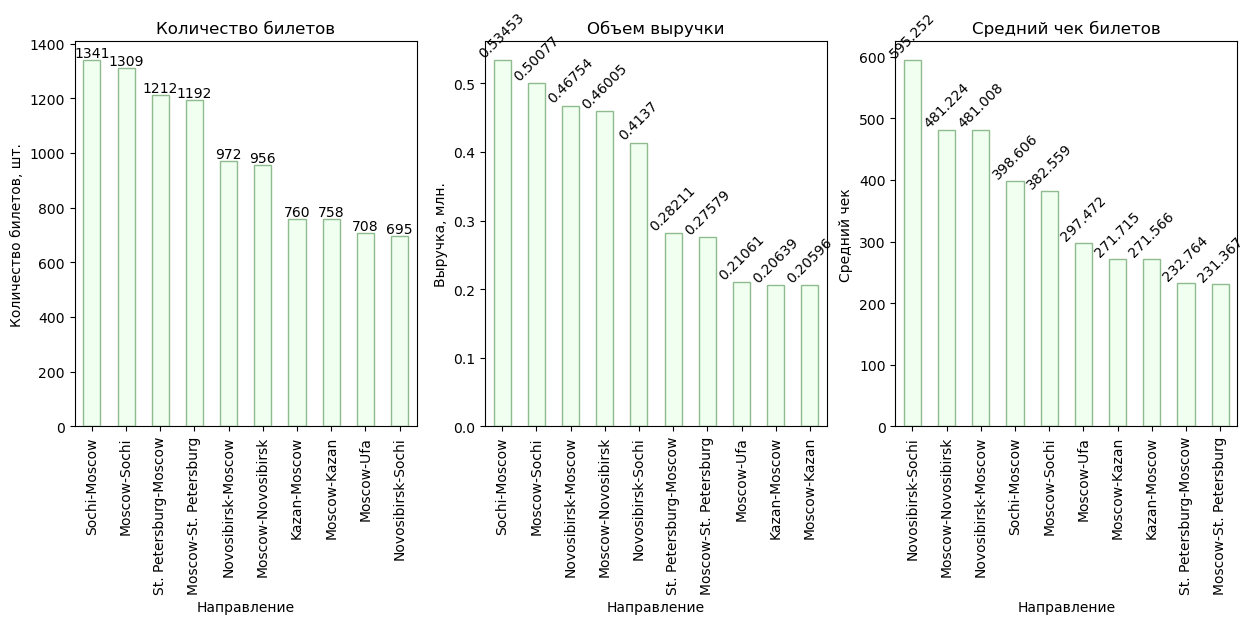

In [119]:
# Визуализация отчета 

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) # создаем сетку 1х3 для размещения графиков

# Создание отдельного графика для отображениия различий в количестве купленных билетов по популярным направлениям 
ax = top_10_route_vvl.plot(kind='bar',
                           x='route',
                           y='count_tickets',
                           title='Количество билетов',
                           xlabel='Направление',
                           ylabel='Количество билетов, шт.',
                           color='honeydew',
                           edgecolor='darkseagreen',
                           legend=False,
                           ax=axs[0]) # размещаем график в первой из трех созданных ячеек 

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

# Создание графика для отображения различий в общем объеме выручки, полученной от продажи билетов по популряным направлениям
ax = top_10_route_vvl.sort_values(by='revenue_(million)', ascending=False).plot(kind='bar',
                                                                                x='route',
                                                                                y='revenue_(million)',
                                                                                title='Объем выручки',
                                                                                xlabel='Направление',
                                                                                ylabel='Выручка, млн.',
                                                                                color='honeydew',
                                                                                edgecolor='darkseagreen',
                                                                                legend=False,
                                                                                ax=axs[1]) # размещаем график во второй из трех созданных ячеек

ax.bar_label(ax.containers[0], rotation=45) # Добавим подписи со значениями

# Создание графика для отображения различий в среднем чеке между билетами по популярным направлениям
ax = top_10_route_vvl.sort_values(by='mean_revenue', ascending=False).plot(kind='bar',
                                                                           x='route',
                                                                           y='mean_revenue',
                                                                           title='Средний чек билетов',
                                                                           xlabel='Направление',
                                                                           ylabel='Средний чек',
                                                                           color='honeydew',
                                                                           edgecolor='darkseagreen',
                                                                           legend=False,
                                                                           ax=axs[2]) # размещаем график в третьей из трех созданных ячеек

ax.bar_label(ax.containers[0], rotation=45) # Добавим подписи со значениями

plt.show()

<div class="alert alert-block alert-success">
    
#### Вывод

1. Направление Сочи-Москва и Москва-Сочи являются абсолютными лидерами по объему продаж (1341 и 1309 билетов) и объему выручки (0,53453 и 0,50077 млн.). Однако данные направления не являются абсолютными лидерами по среднему чеку на билет: средний чек 398,606 и 382,559 занимают промежуточное положение в ценовой сетке компании - выше бюджетных направлений (СПб-Москва), но ниже премиальных дальнемагистральных перелетов (Новосибирск-Сочи). Это отражает стратегию дифференцированного ценообразования, учитывающую как курортный статус направления, так и необходимость сохранения конкурентоспособности. Средние чеки по направлению туда и обратно различаются в среднем на 4% в пользу направления "Сочи-Москва", что может быть вызвано разницей в количестве купленных билетов либо гибкой ценовой политикой в отношении установления цен в зависимости от направления вылета: люди, прилетевшие в Сочи на курорт купят билет домой, в Москву, по любой цене, так как им точно нужно вернутся, а вот решение о покупке билета из Москва в Сочи может быть отрицательным из-за завышенной цены.
2. Направление Москва-Санкт-Петербург и Санкт-Петербург-Москва - классические бизнес-направления с высоким спросом (1212 и 1192 купленных билета), но низкой ценой (минимальный средний чек в сравнении с другими популярными направлениями (232,764 и 231,367). Занижение цены обусловлено высокой конкуренцией с альтернативными видами транспорта (поезда, автобусы). Авиакомпания сознательно принимает выбор в пользу увеличения объема продаж, а не выручки. За счет высокого спроса на направление, данная политика ценообразования не навредила объему выручки.
3. Новосибирск-Москва и Москва-Новосибирск - средний спрос на направление (972 и 956 купленных билета), вызванный деловыми поездками или визитами к родственникам. Направление является лидером по среднему чеку перелета, вызванное дальним расстояние. Средний чек на направление туда и обратно не различается (481), что говорит о единой политике ценообразования на дальние маршруты. За счет высокого среднего чека сохраняет лидирующий объем выручки (0,46754 и 0,46005 млн.).
4. Казань-Москва и Москва-Казань - направление пользуется популярностью, но уже не занимает лидирующих позиций. Объем продаж 760 и 758 билетов. Средний чек по направлению туда и обратно не различается (272). Занимает нишу между бюджетными и премиальными перелетами, демонстрируя оптимальное соотношение цены и спроса. Пользуется меньшим спросом по сравнению с направлением Москва-СПб, поэтому занимает крайние положение по объему выручки.
5. Москва-Уфа - 708 купленных билетов. Стабильное региональное направление с средним чеком 297. Занимает промежуточное положение между ближними и дальними маршрутами, демонстрируя предсказуемую доходность.
6. Новосибирск-Сочи не лидирует по объему продаж (695 билетов). Однако является абсолютным лидером по величине среднего чека (595), что обусловлено сочетанием дальности перелета и курортным направлением. При относительно небольшом объеме продаж генерирует значительную выручку (0,4137 млн.).

In [120]:
# Проведем анализ популярных направлений для Международных Воздушных Линий 
# Для опредление топ-10 популряных направлений буду использовать количество купленных билетов

# Создадим отдельный датасет, содержащий информацию только о перелетах МВЛ 
df_mvl = df_new.query('route_flight_type == "МВЛ"')
report_mvl = df_mvl.pivot_table(index='city-city',
                                aggfunc=['count', lambda x: round(x.mean(), 3), lambda x: x.sum() / 1_000_000],
                                values='revenue_amount').reset_index().set_axis(['route', 'count_tickets', 'mean_revenue', 'revenue_(million)'], 
                                                                                axis='columns').sort_values(by='count_tickets', ascending=False)

top_10_route_mvl = report_mvl.head(10)
top_10_route_mvl

,route,count_tickets,mean_revenue,revenue_(million)
170,Moscow-Osh,154,468.182,0.07210
102,Khudzhand-Moscow,146,665.479,0.09716
229,Osh-Moscow,136,595.000,0.08092
161,Moscow-Khudzhand,130,451.923,0.05875
214,Novosibirsk-Osh,122,425.656,0.05193
202,Novosibirsk-Bishkek,121,405.289,0.04904
104,Khudzhand-Novosibirsk,116,497.759,0.05774
231,Osh-Novosibirsk,116,499.741,0.05797
141,Moscow-Antalya,107,438.318,0.04690
30,Bishkek-Novosibirsk,102,473.529,0.04830


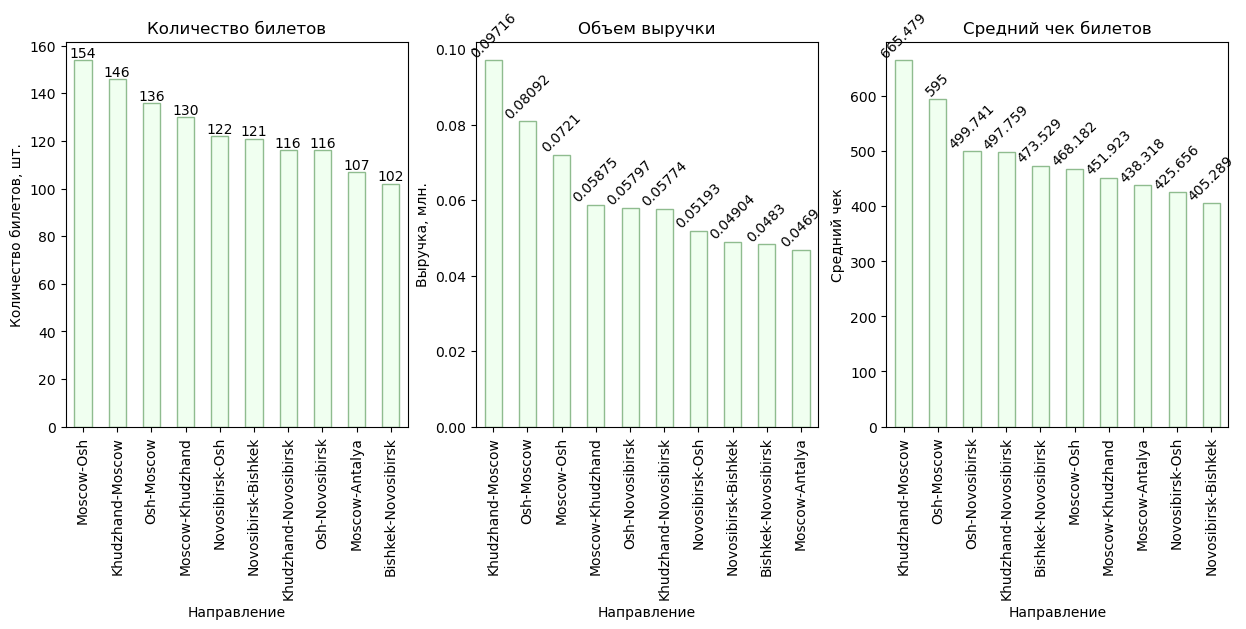

In [121]:
# Визуализация отчета 

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) # создаем сетку 1х3 для размещения графиков

# Создание отдельного графика для отображениия различий в количестве купленных билетов по популярным направлениям 
ax = top_10_route_mvl.plot(kind='bar',
                           x='route',
                           y='count_tickets',
                           title='Количество билетов',
                           xlabel='Направление',
                           ylabel='Количество билетов, шт.',
                           color='honeydew',
                           edgecolor='darkseagreen',
                           legend=False,
                           ax=axs[0]) # размещаем график в первой из трех созданных ячеек 

ax.bar_label(ax.containers[0]) # Добавим подписи со значениями

# Создание графика для отображения различий в общем объеме выручки, полученной от продажи билетов по популряным направлениям
ax = top_10_route_mvl.sort_values(by='revenue_(million)', ascending=False).plot(kind='bar',
                                                                                x='route',
                                                                                y='revenue_(million)',
                                                                                title='Объем выручки',
                                                                                xlabel='Направление',
                                                                                ylabel='Выручка, млн.',
                                                                                color='honeydew',
                                                                                edgecolor='darkseagreen',
                                                                                legend=False,
                                                                                ax=axs[1]) # размещаем график во второй из трех созданных ячеек

ax.bar_label(ax.containers[0], rotation=45) # Добавим подписи со значениями

# Создание графика для отображения различий в среднем чеке между билетами по популярным направлениям
ax = top_10_route_mvl.sort_values(by='mean_revenue', ascending=False).plot(kind='bar',
                                                                           x='route',
                                                                           y='mean_revenue',
                                                                           title='Средний чек билетов',
                                                                           xlabel='Направление',
                                                                           ylabel='Средний чек',
                                                                           color='honeydew',
                                                                           edgecolor='darkseagreen',
                                                                           legend=False,
                                                                           ax=axs[2]) # размещаем график в третьей из трех созданных ячеек

ax.bar_label(ax.containers[0], rotation=45) # Добавим подписи со значениями

plt.show()

<div class="alert alert-block alert-success">

#### Вывод 

1. Москва-Ош и Ош-Москва - являются лидерами по объему продаж, хоть и занимают разные позиции в рейтинге (154 и 136 купленных билетов соотвественно). Средний чек по билетам в разные направления отличается на 126,818 в пользу направления Ош-Москва. Высокая наценка связана с тем, что, прилетев в город Ош из Москвы, людям точно потребуется билет обратно и они будут готовы купить его по "заоблочной" цене. В связи с высокми средним чеком направление Ош-Москва занимает второе по лидерству положение в объеме выручки (0,08092 млн.). Попуряность перелета позволяет направлению Москва-Ош получить выручки равную 0,0721 млн.
2. Худжанд-Москва и Москва-Худжанд. Демонстрируют яркую асимметрию. При схожем пассажиропотоке (146 и 130 билетов) средний чек из Худжанда в Москву выше на 213,556, что делает это направление абсолютным лидером по выручке (0,09716 млн). Направление Москва-Худжанд, напротив, имеет один из самых низких средних чеков, генерируя выручку 0,05875 млн. Данную тенденцию можно объяснить той же причиной, что и в пункте 1.

Данная тенденция в различии средних чеков демонтрируют все направления. Направление из за границы в Россию имеет больший средний чек. В связи с эти эти направления генерируют большую выручку по отношению к тем же направлениям из России за границу. 

3. Худжанд-Новосибирск: это направление, как и другие из Худжанда, характеризуется высоким средним чеком (497,759). При пассажиропотоке в 116 билетов оно приносит солидную выручку в 0,05774 млн.

4. Москва-Анталья. Имеет стабильный спрос (107 билетов) и средний чек, принося выручку 0,04690 млн.

In [122]:
# Дополнительное исследование выручки 
revenue_vvl = df_new.query('route_flight_type == "ВВЛ"')['revenue_amount'].sum()
revenue_mvl = df_new.query('route_flight_type == "МВЛ"')['revenue_amount'].sum()
revenue_top_10_vvl = top_10_route_vvl['revenue_(million)'].sum() * 1_000_000
revenue_top_10_mvl = top_10_route_mvl['revenue_(million)'].sum() * 1_000_000
revenue_w = (((top_10_route_vvl['revenue_(million)'].sum() * 1_000_000) + (top_10_route_mvl['revenue_(million)'].sum() * 1_000_000)) / df_new['revenue_amount'].sum()) * 100
revenue_w_vvl = ((top_10_route_vvl['revenue_(million)'].sum() * 1_000_000) / df_new.query('route_flight_type == "ВВЛ"')['revenue_amount'].sum()) * 100
revenue_w_mvl = ((top_10_route_mvl['revenue_(million)'].sum() * 1_000_000) / df_new.query('route_flight_type == "МВЛ"')['revenue_amount'].sum()) * 100

In [123]:
print(f'Общая выручка по ВВЛ составила: {revenue_vvl}')
print(f'Общая выручка по МВЛ составила: {revenue_mvl}')
print(f'Суммарная выручка по 10 популярнейшим направлениям ВВЛ составила: {round(revenue_top_10_vvl)}')
print(f'Суммарная выручка по 10 популярнейшим направлениям МВЛ составила: {round(revenue_top_10_mvl)}')
print(f'Доля выручки, которую принесли суммарно 10 популярнейших направлений ВВЛ и МВЛ от общей выручки составила: {round(revenue_w, 3)}%')
print(f'Доля выручки, которую принесли 10 популярнейших направлений ВВЛ от общей выручки по ВВЛ составила: {round(revenue_w_vvl, 3)}%')
print(f'Доля выручки, которую принесли 10 популярнейших направлений МВЛ от общей выручки по МВЛ составила: {round(revenue_w_mvl, 3)}%')

Общая выручка по ВВЛ составила: 19610480
Общая выручка по МВЛ составила: 1993210
Суммарная выручка по 10 популярнейшим направлениям ВВЛ составила: 3557450
Суммарная выручка по 10 популярнейшим направлениям МВЛ составила: 620810
Доля выручки, которую принесли суммарно 10 популярнейших направлений ВВЛ и МВЛ от общей выручки составила: 19.34%
Доля выручки, которую принесли 10 популярнейших направлений ВВЛ от общей выручки по ВВЛ составила: 18.141%
Доля выручки, которую принесли 10 популярнейших направлений МВЛ от общей выручки по МВЛ составила: 31.146%


<div class="alert alert-block alert-success">

#### Вывод 

Таким образом, дополнительный анализ выручки позволяет сделать вывод о том, что авиакомпания работает в основном внутри России - 91% выручки приносят внутренние перелеты (19610480 против 1993210). Международные рейсы дают только 9% выручки.

Самые популярные международные направления приносят треть всей выручки от заграничных рейсов (31,146%), а внутри России доходы распределены более равномерно - топ-10 маршрутов дают меньше 20% выручки, то есть международный бизнес зависит от нескольких ключевых направлений, а российский - более устойчив, так как выручка приходит со множества разных маршрутов.

#### Задание 3.6

3.6 Определите есть ли зависимость выручки от других признаков. Постройте матрицу корреляций.

In [124]:
# Для определения зависимости выручки от других признаков воспользуемся точечно-бисериальной корреляцией.
# Точечно-бисериальная корреляция - измеряет силу и направление взаимосвязи между двумя переменными: 
# одна переменная является непрерывной, а другая - бинарной (дихотомической).
# Перейдем от категориальных переменных к бинарным

# Создаем новый датафрейм 
df_corr = df_new 

# 1. passenger_type
passenger_type_dict = {'AD': 1, 
                       'CHD': 0,
                       'INF': 0} # словарь для перевода категориальной переменной passenger_type в бинарную 

df_corr['passenger_type'] = df_corr['passenger_type'].map(passenger_type_dict) # заменяем категориальную переменную на бинарную

In [125]:
# 2. route_flight_type
route_flight_type_dict = {'ВВЛ': 1, 
                          'МВЛ': 0} # словарь для перевода категориальной переменной route_flight_type в бинарную 

df_corr['route_flight_type'] = df_corr['route_flight_type'].map(route_flight_type_dict) # заменяем категориальную переменную на бинарную

In [126]:
# 3. ffp_flag
ffp_flag_dict = {'NOT_FFP': 0, 
                 'FFP': 1} # словарь для перевода категориальной переменной ffp_flag в бинарную 

df_corr['ffp_flag'] = df_corr['ffp_flag'].map(ffp_flag_dict) # заменяем категориальную переменную на бинарную

In [127]:
# 4. sale_type
sale_type_dict = {'ONLINE': 1, 
                  'OFFLINE': 0} # словарь для перевода категориальной переменной sale_type в бинарную 

df_corr['sale_type'] = df_corr['sale_type'].map(sale_type_dict) # заменяем категориальную переменную на бинарную

In [128]:
# Рассмотри зависимость выручки от сезонов зима и лето, как полных противоположностей друг друга по объему выручки 
# 5. issue_season = Зима 
issue_season_winter_dict = {'Зима': 1, 
                            'Весна': 0,
                            'Лето': 0,
                            'Осень': 0} # рассмотрим отдельно зимний сезон  

df_corr['issue_season_winter'] = df_corr['issue_season'].map(issue_season_winter_dict) # заменяем категориальную переменную на бинарную

# 6. issue_season = Лето 
issue_season_summer_dict = {'Зима': 0, 
                            'Весна': 0,
                            'Лето': 1,
                            'Осень': 0} # рассмотрим отдельно летний сезон  

df_corr['issue_season_summer'] = df_corr['issue_season'].map(issue_season_summer_dict) # заменяем категориальную переменную на бинарную

In [129]:
# Рассмотри зависимость выручки от типов пассажиров по времени покупки билета: в последний момент и очень заранее  
# 7. customer_category = Покупка в последний момент 
customer_category_last_moment_dict = {'Покупка в последний момент': 1, 
                                      'Стандартная покупка': 0,
                                      'Заблаговременная покупка': 0,
                                      'Очень ранняя покупка': 0} # рассмотрим отдельно покупки билетов в последний момент  

df_corr['customer_category_last_moment'] = df_corr['customer_category'].map(customer_category_last_moment_dict) # заменяем категориальную переменную на бинарную

# 8. customer_category = Очень ранняя покупка 
customer_category_very_early_dict = {'Покупка в последний момент': 0, 
                                     'Стандартная покупка': 0,
                                     'Заблаговременная покупка': 0,
                                     'Очень ранняя покупка': 1} # рассмотрим отдельно покупки билетов очень заранее  

df_corr['customer_category_very_early'] = df_corr['customer_category'].map(customer_category_very_early_dict) # заменяем категориальную переменную на бинарную

In [130]:
df_corr.head() # проверка

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,...,issue_season,count_days,customer_category,departure_city_name,dest_city_name,city-city,issue_season_winter,issue_season_summer,customer_category_last_moment,customer_category_very_early
0,2021-12-07,2022-01-11,1,200,MOW,KGD,1,0,1,2021,...,Зима,35,Заблаговременная покупка,Moscow,Kaliningrad,Moscow-Kaliningrad,1,0,0,0
1,2021-12-31,2022-01-03,1,610,UUS,OVB,1,0,0,2021,...,Зима,3,Покупка в последний момент,Yuzhno-sakhalinsk,Novosibirsk,Yuzhno-sakhalinsk-Novosibirsk,1,0,1,0
2,2021-11-28,2022-01-04,1,390,KGD,MOW,1,1,1,2021,...,Осень,37,Заблаговременная покупка,Kaliningrad,Moscow,Kaliningrad-Moscow,0,0,0,0
3,2021-12-08,2022-01-05,1,190,VOZ,MOW,1,0,1,2021,...,Зима,28,Стандартная покупка,Voronezh,Moscow,Voronezh-Moscow,1,0,0,0
4,2021-12-08,2022-01-12,1,190,MOW,KRR,1,1,0,2021,...,Зима,35,Заблаговременная покупка,Moscow,Krasnodar,Moscow-Krasnodar,1,0,0,0


In [158]:
# Строим точечно-бисериальную корреляцию

binary_variables = ['revenue_amount', 'route_flight_type', 'passenger_type', 'ffp_flag', 'sale_type', 'issue_season_winter',	
                    'issue_season_summer', 'customer_category_last_moment', 'customer_category_very_early']

print('Точечно-бисериальная корреляция зависимости выручки от других признаков')
df_corr_1 = [] # для удобства далее данные будут оформлены в таблицу
for i in binary_variables:
    statistic, pvalue = st.pointbiserialr(df_corr['revenue_amount'], df_corr[i])
    print(f'{i}: {statistic:.3f} (pvalue = {pvalue:.3f})')
    df_corr_1.append({'sign': i,
                     'statistic': statistic})

Точечно-бисериальная корреляция зависимости выручки от других признаков
revenue_amount: 1.000 (pvalue = 0.000)
route_flight_type: -0.101 (pvalue = 0.000)
passenger_type: 0.074 (pvalue = 0.000)
ffp_flag: -0.046 (pvalue = 0.000)
sale_type: -0.162 (pvalue = 0.000)
issue_season_winter: -0.138 (pvalue = 0.000)
issue_season_summer: 0.183 (pvalue = 0.000)
customer_category_last_moment: -0.017 (pvalue = 0.000)
customer_category_very_early: 0.021 (pvalue = 0.000)


In [159]:
# Оформление полученных данных в таблицу 
point_biserial_correlation = pd.DataFrame(data=df_corr_1)
point_biserial_correlation

,sign,statistic
0,revenue_amount,1.000000
1,route_flight_type,-0.100734
2,passenger_type,0.074033
3,ffp_flag,-0.046345
4,sale_type,-0.162307
5,issue_season_winter,-0.138485
6,issue_season_summer,0.182627
7,customer_category_last_moment,-0.017090
8,customer_category_very_early,0.021250


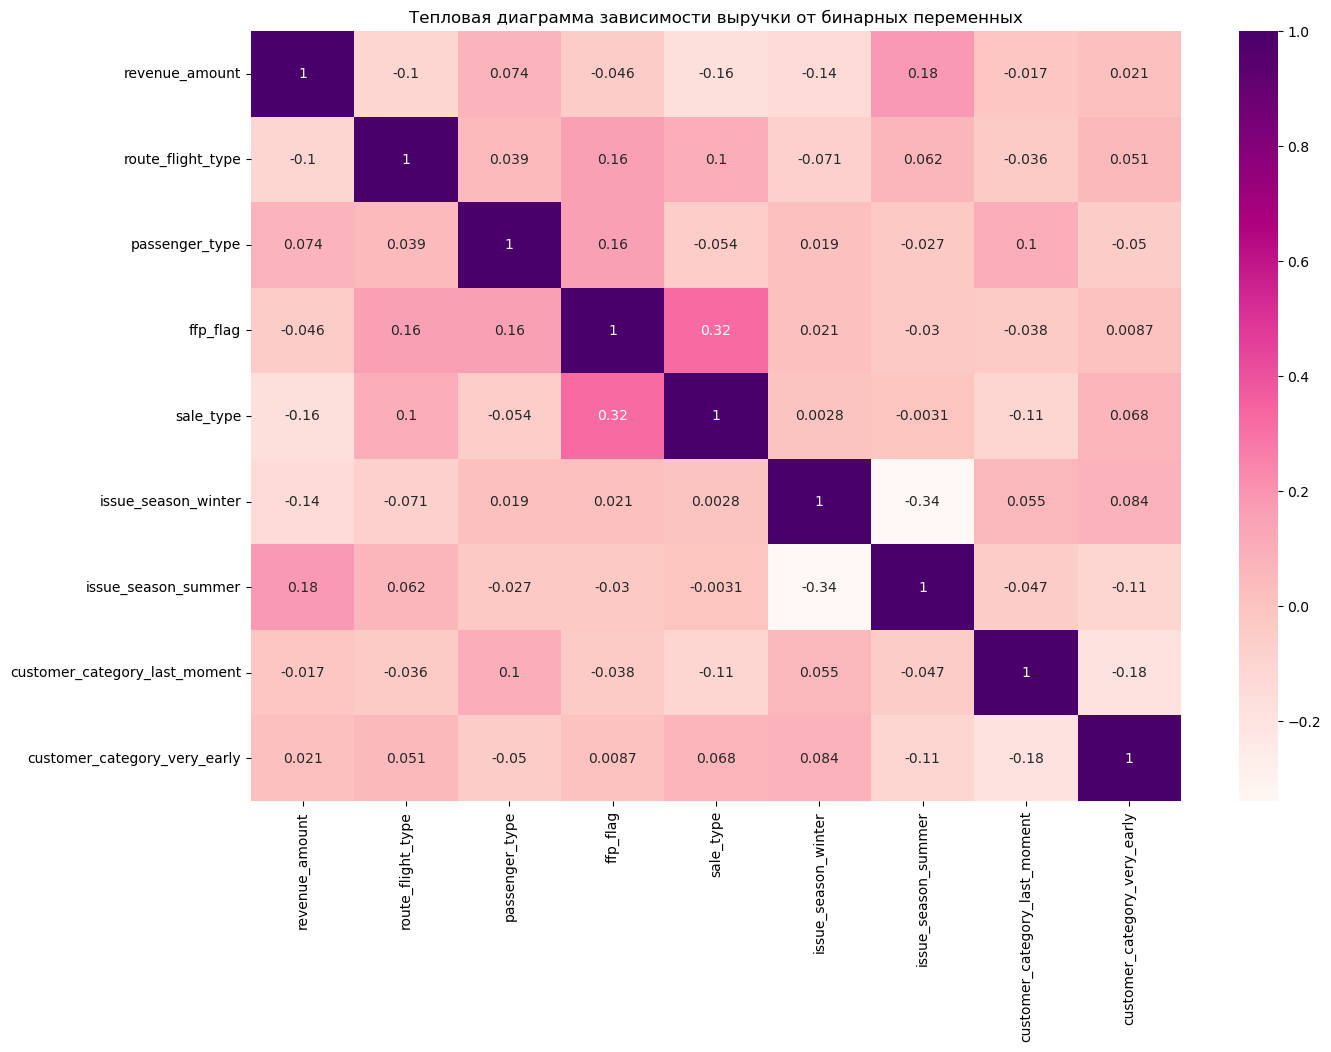

In [160]:
# Рассчитает коэффициент корреляции 
df_correlation = df_corr[['revenue_amount', 'route_flight_type', 'passenger_type', 'ffp_flag', 'sale_type', 'issue_season_winter',	
                    'issue_season_summer', 'customer_category_last_moment', 'customer_category_very_early']] 
# Таблица, содержащая только данные об исследуемых признаках 
plt.figure(figsize=(15,10))
correlation_matrix = df_correlation.corr() # матрица корреляции

# Визуализируем матрицу корреляции с помощью тепловой диаграммы 
sns.heatmap(correlation_matrix, annot=True, cmap='RdPu')
plt.title('Тепловая диаграмма зависимости выручки от бинарных переменных')

plt.show()

In [139]:
# Значения, в точечно-бисериальной корреляции не отличаются от значений коэффициента корреляции

# Повторим тоже самое на данных, очищенных от выбросов 
# Для определения зависимости выручки от других признаков воспользуемся точечно-бисериальной корреляцией.
# Точечно-бисериальная корреляция - измеряет силу и направление взаимосвязи между двумя переменными: 
# одна переменная является непрерывной, а другая - бинарной (дихотомической).
# Перейдем от категориальных переменных к бинарным

# Создаем новый датафрейм 
df_not_ejection_corr = df_not_ejection 

# 1. passenger_type
passenger_type_dict = {'AD': 1, 
                       'CHD': 0,
                       'INF': 0} # словарь для перевода категориальной переменной passenger_type в бинарную 

df_not_ejection_corr['passenger_type'] = df_not_ejection_corr['passenger_type'].map(passenger_type_dict) # заменяем категориальную переменную на бинарную

In [140]:
# 2. route_flight_type
route_flight_type_dict = {'ВВЛ': 1, 
                          'МВЛ': 0} # словарь для перевода категориальной переменной route_flight_type в бинарную 

df_not_ejection_corr['route_flight_type'] = df_not_ejection_corr['route_flight_type'].map(route_flight_type_dict) # заменяем категориальную переменную на бинарную

In [141]:
# 3. ffp_flag
ffp_flag_dict = {'NOT_FFP': 0, 
                 'FFP': 1} # словарь для перевода категориальной переменной ffp_flag в бинарную 

df_not_ejection_corr['ffp_flag'] = df_not_ejection_corr['ffp_flag'].map(ffp_flag_dict) # заменяем категориальную переменную на бинарную

In [142]:
# 4. sale_type
sale_type_dict = {'ONLINE': 1, 
                  'OFFLINE': 0} # словарь для перевода категориальной переменной sale_type в бинарную 

df_not_ejection_corr['sale_type'] = df_not_ejection_corr['sale_type'].map(sale_type_dict) # заменяем категориальную переменную на бинарную

In [143]:
# Рассмотри зависимость выручки от сезонов зима и лето, как полных противоположностей друг друга по объему выручки 
# 5. issue_season = Зима 
issue_season_winter_dict = {'Зима': 1, 
                            'Весна': 0,
                            'Лето': 0,
                            'Осень': 0} # рассмотрим отдельно зимний сезон  

df_not_ejection_corr['issue_season_winter'] = df_not_ejection_corr['issue_season'].map(issue_season_winter_dict) # заменяем категориальную переменную на бинарную

# 6. issue_season = Лето 
issue_season_summer_dict = {'Зима': 0, 
                            'Весна': 0,
                            'Лето': 1,
                            'Осень': 0} # рассмотрим отдельно летний сезон  

df_not_ejection_corr['issue_season_summer'] = df_not_ejection_corr['issue_season'].map(issue_season_summer_dict) # заменяем категориальную переменную на бинарную

In [144]:
# Рассмотри зависимость выручки от типов пассажиров по времени покупки билета: в последний момент и очень заранее  
# 7. customer_category = Покупка в последний момент 
customer_category_last_moment_dict = {'Покупка в последний момент': 1, 
                                      'Стандартная покупка': 0,
                                      'Заблаговременная покупка': 0,
                                      'Очень ранняя покупка': 0} # рассмотрим отдельно покупки билетов в последний момент  

df_not_ejection_corr['customer_category_last_moment'] = df_not_ejection_corr['customer_category'].map(customer_category_last_moment_dict) # заменяем категориальную переменную на бинарную

# 8. customer_category = Очень ранняя покупка 
customer_category_very_early_dict = {'Покупка в последний момент': 0, 
                                     'Стандартная покупка': 0,
                                     'Заблаговременная покупка': 0,
                                     'Очень ранняя покупка': 1} # рассмотрим отдельно покупки билетов очень заранее  

df_not_ejection_corr['customer_category_very_early'] = df_not_ejection_corr['customer_category'].map(customer_category_very_early_dict) # заменяем категориальную переменную на бинарную

In [145]:
df_not_ejection.head() # проверка

,issue_date,flight_date,passenger_type,revenue_amount,departure_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,issue_year,issue_month,issue_season,count_days,customer_category,departure_city_name,dest_city_name,issue_season_winter,issue_season_summer,customer_category_last_moment,customer_category_very_early
0,2021-12-07,2022-01-11,1,200,MOW,KGD,1,0,1,2021,Декабрь,Зима,35,Заблаговременная покупка,Moscow,Kaliningrad,1,0,0,0
1,2021-12-31,2022-01-03,1,610,UUS,OVB,1,0,0,2021,Декабрь,Зима,3,Покупка в последний момент,Yuzhno-sakhalinsk,Novosibirsk,1,0,1,0
2,2021-11-28,2022-01-04,1,390,KGD,MOW,1,1,1,2021,Ноябрь,Осень,37,Заблаговременная покупка,Kaliningrad,Moscow,0,0,0,0
3,2021-12-08,2022-01-05,1,190,VOZ,MOW,1,0,1,2021,Декабрь,Зима,28,Стандартная покупка,Voronezh,Moscow,1,0,0,0
4,2021-12-08,2022-01-12,1,190,MOW,KRR,1,1,0,2021,Декабрь,Зима,35,Заблаговременная покупка,Moscow,Krasnodar,1,0,0,0


In [161]:
# Строим точечно-бисериальную корреляцию

binary_variables = ['revenue_amount', 'route_flight_type', 'passenger_type', 'ffp_flag', 'sale_type', 'issue_season_winter',	
                    'issue_season_summer', 'customer_category_last_moment', 'customer_category_very_early']

print('Точечно-бисериальная корреляция зависимости выручки от других признаков')
df_not_ejection_corr_1 = [] # для удобства далее данные будут оформлены в таблицу
for i in binary_variables:
    statistic, pvalue = st.pointbiserialr(df_not_ejection_corr['revenue_amount'], df_not_ejection_corr[i])
    print(f'{i}: {statistic:.3f} (pvalue = {pvalue:.3f})')
    df_not_ejection_corr_1.append({'sign': i,
                                   'statistic': statistic})

Точечно-бисериальная корреляция зависимости выручки от других признаков
revenue_amount: 1.000 (pvalue = 0.000)
route_flight_type: -0.101 (pvalue = 0.000)
passenger_type: 0.074 (pvalue = 0.000)
ffp_flag: -0.052 (pvalue = 0.000)
sale_type: -0.166 (pvalue = 0.000)
issue_season_winter: -0.154 (pvalue = 0.000)
issue_season_summer: 0.193 (pvalue = 0.000)
customer_category_last_moment: -0.048 (pvalue = 0.000)
customer_category_very_early: 0.037 (pvalue = 0.000)


In [166]:
# Оформление полученных данных в таблицу 
point_biserial_correlation_1 = pd.DataFrame(data=df_not_ejection_corr_1)
point_biserial_correlation_1

,sign,statistic
0,revenue_amount,1.000000
1,route_flight_type,-0.101323
2,passenger_type,0.073758
3,ffp_flag,-0.051972
4,sale_type,-0.166358
5,issue_season_winter,-0.153772
6,issue_season_summer,0.192901
7,customer_category_last_moment,-0.048279
8,customer_category_very_early,0.036761


<div class="alert alert-block alert-danger">

#### Вывод: 
(Вывод сделан по коэффициенту корреляции для очищенных от выбросов данных, так как коэффициент корреляции Пирсона крайне чувствителен к выбросам)
1. Слабые коэффициенты корреляции (|r| > 0.1):

   - Способ покупки (r = -0.17). Слабая отрицательная корреляция, которая указывает на то, что покупки авиабилетов online дешевле и выручка от увеличения продаж online будет снижаться. Offline-продажи приносят больше выручки. Возможные причины: более дорогие билеты продают в офисах, где оказывают дополнительыне услуги, например консультации менеджера.
   - Сезон покупки (Лето: r = 0.19, Зима: r = -0.15). Слабая положительная и отрицательная корреляция соответственно. Данные коэффициенты подтверждают ранее сделанный вывод о более высокой выручке в летние периоды и более низкой в зимние.
   - Тип перелета (r = -0.101). Слабая отрицательная корреляция, которая указывает на снижение выручки при увеличении числа перелетов по Внутренним Воздушным Линиям.
  
2. Практически отсутствующая корреляция:

   - Тип пассажира (r = 0.074). Почти отсутствующая положительная корреляция, которая говорит о том, что взрослые пассажиры приносят немного большую выручку по сравнению с детьми и неопределенной категорией. Взрослые покупатели - более платежеспособны и их количество сильно превышает детей. Также ранее было установлено, что в данной авиакомпании могут действовать пониженные тарифы для детей.
   - Использование программы лояльности (r = -0.052). Отрицательная корреляция, указывающая на то, что использование программы лояльности приносит немного меньшую выручку.
   - Категория пассажира от времени покупки билета (В последний момент: r = -0,048, очень ранняя покупка: r = 0.037). Выручка по категории клиентов, покупающих билеты в последний момент, как было установлено выше, растет. Однако коэффициент корреляции демонстрирует обратную величину, что может быть вызвано тем, что мы рассматриваем крайние категории и не рассмотриваем две категории между ними, количество покупателей в которых выше. 

<div class="alert alert-block alert-success">

#### Общий вывод по работе:

Проведенный комплексный анализ данных авиакомпании позволяет выявить ключевые закономерности и сформировать стратегические рекомендации для бизнеса.

##### Основные результаты исследования:
1. Структура бизнеса и рынок: 91% выручки генерируется внутренними перелетами, что подтверждает ориентацию компании на российский рынок. Международные направления (9% выручки) характеризуются зависимостью от нескольких ключечных маршрутов, в то время как внутренний бизнес более устойчив и разнообразен.
2. Сезонность и динамика спроса: летний период демонстрирует пиковые показатели выручки (+18% корреляция), зимний сезон характеризуется снижением доходности (-14% корреляция), осень и зиму следует рассматривать как единый низкий сезон без статистически значимых различий.
3. Ценовая политика и стратегия:
   
   - Динамическое ценообразование подтверждено статистически: билеты, купленные в последний момент (0-7 дней до вылета), стоят дороже;
   - Offline-продажи приносят на 16% больше выручки по сравнению с online;
   - Топ-маршруты демонстрируют разную стратегию: Москва-Санкт-Петербург: стратегия низких цен для максимизации объемов, Новосибирск-Сочи: высокий средний чек, вызванный длинными перелетом, Международные направления: асимметричное ценообразование (дороже из-за рубежа в Россию).

4. Клиентская база и программы лояльности: взрослые пассажиры составляют основу клиентской базы, детский сегмент важен для формирования семейной лояльности, текущая программа лояльности неэффективна и требует пересмотра, категории клиентов по времени покупки статистически значимо различаются по вкладу в выручку.
5. География и маршрутная сеть:

   - Лидирующие направления: Сочи-Москва и Москва-Сочи по объемам продаж;
   - Максимальный средний чек: Новосибирск-Сочи (курортное и дальнее направление);
   - Международные направления показывают устойчивый спрос с Ошем и Худжандом.

##### Стратегические рекомендации: 
1. Оптимизация сезонности: разработка стимулирующих программ для низкого сезона (январь, февраль и октябрь (осень и зима));
2. Модернизация способов оплаты: стимулирование офлайн-продаж для дорогих билетов и пересмотр онлайн-скидочной политики;
3. Кардинальный пересмотр или запуск новой программы с фокусом на увеличение среднего чека;
4. Поддержка высокодоходных дальних и курортных направлений и сохранение конкурентных цен на популярные маршруты.